# 06 — Tam Mimari: Parçaları Birleştirip Hazır Bir Modelin İçine Bakmak

**Önkoşul:** 01-05. Şimdiye kadar tek tek parçaları **sıfırdan** kurduk: token'lar (01), embedding'ler (02), attention (03), multi-head (04), konum bilgisi (05). Bu notebook'ta yön değiştiriyoruz: **hazır, gerçekten eğitilmiş** iki modeli (GPT-2 small ve BERT-base) açıp içine bakacağız ve kendi parçalarımızın orada aynı işi yaptığını **sayıyla** kanıtlayacağız.

### Bu notebook'un 4 ana fikri

1. **Tam bir Transformer bloğu = 03-05'te yazdıklarımız + iki yeni parça.** Attention kelimeler arasında bilgi taşıyor. **FFN** her kelimenin toplanan bilgiyle tek başına "düşünmesini" sağlıyor. **Residual + LayerNorm** ise bu işlemlerin üst üste binerken bozulmamasını sağlıyor.
2. **GPT-2 = aynı bloğun 12 kez üst üste konması.** Kendi yazdığımız ~30 satırlık kod, GPT-2'nin logit'lerini yeniden üretiyor (fark ~1e-4, yani float yuvarlama hatası).
3. **Causal mask = decoder-only modelin kuralı.** GPT-2'de bir kelime sadece solundakileri görüyor. BERT'te herkes herkesi görüyor. Deneyle ikisini ayırt edeceğiz.
4. **Üç aile:** encoder-only (BERT), decoder-only (GPT), encoder-decoder (T5, orijinal Transformer). Fark neredeyse tamamen **hangi kelimenin kimi görebildiği**.

Her bölümde önce **sezgi**, sonra **kod**, sonra **"Ne gördük?"** geliyor. "(İsteğe bağlı)" kısımları ilk okumada atlayabilirsin.

**Not (internet):** Bu notebook ilk çalıştırmada `gpt2` (~500 MB), `bert-base-uncased` (~440 MB) ve `t5-small` (~240 MB) modellerini Hugging Face'ten indiriyor. İndirdikten sonra önbellekten geliyor. Modeller **İngilizce** eğitilmiş; Türkçe'ye Egzersiz 4'te bakacağız.

**Reprodüksiyon notu:** Modeller eğitilmiş olduğundan burada rastgelelik neredeyse yok. Kullanılan global isimler: `gpt`, `tr_gpt`, `tok_gpt`, `bert`, `tok_bert`, `ids_eif`, `toks_eif`, `hs_eif`, `out_eif`, `ln_manual`, `gelu_manual`, `attn_manual`, `mlp_manual`, `block_manual`, `forward_manual`. Egzersizlerde bunları ezme.

In [140]:
import time, math
import numpy as np
import matplotlib.pyplot as plt
import torch
import transformers
from transformers import AutoTokenizer, GPT2LMHeadModel, BertForMaskedLM
from dotenv import load_dotenv
import os
load_dotenv()  # .env dosyasındaki değişkenleri yükle

transformers.logging.set_verbosity_error()
transformers.logging.disable_progress_bar()
torch.set_grad_enabled(False)      # sadece çıkarım yapıyoruz, gradyan gerekmiyor
print("torch", torch.__version__, "| transformers", transformers.__version__)

t0 = time.time()
tok_gpt = AutoTokenizer.from_pretrained("gpt2")
gpt = GPT2LMHeadModel.from_pretrained("gpt2", attn_implementation="eager").eval()   # "eager": attention ağırlıklarını görebilmek için
tok_bert = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = BertForMaskedLM.from_pretrained("bert-base-uncased", attn_implementation="eager").eval()
tr_gpt = gpt.transformer           # GPT-2'nin gövdesi (lm_head hariç)
print(f"iki model yüklendi: {time.time()-t0:.1f} sn")

torch 2.13.0 | transformers 5.17.0
iki model yüklendi: 3.6 sn


## 1) Büyük resim: bir Transformer bloğu neyden oluşuyor?

### Sezgi

Şimdiye kadar bir kelimenin yolculuğunu şöyle çıkardık:

> metin → **token'lar** (01) → **embedding** (02) → **+ konum** (05) → **attention** (03-04)

Ama gerçek bir model bu son adımda durmuyor. Attention'dan sonra iki şey daha var ve blok **12 kez** (GPT-2 small'da) üst üste konuyor:

- **FFN (feed-forward ağı):** Attention kelimelerin birbirinden bilgi toplamasını sağlıyor. Ama toplanan bilgiyi **işleyen** bir yer yok. FFN her kelimeye ayrı ayrı, küçük bir sinir ağı uyguluyor: "topladığım bilgiyle şimdi ne çıkarayım?"
- **Residual (kestirme yol) + LayerNorm:** Her alt parça girdisine **ekleme** yapıyor (`x + parça(x)`), yani eldeki bilgiyi silmiyor, üstüne düzeltme yazıyor. LayerNorm ise sayıların büyüyüp taşmasını engelliyor.

Aşağıdaki şema tam yolu gösteriyor. Boyutlar GPT-2 small için: `T` = kelime sayısı, her kelime 768 sayı.

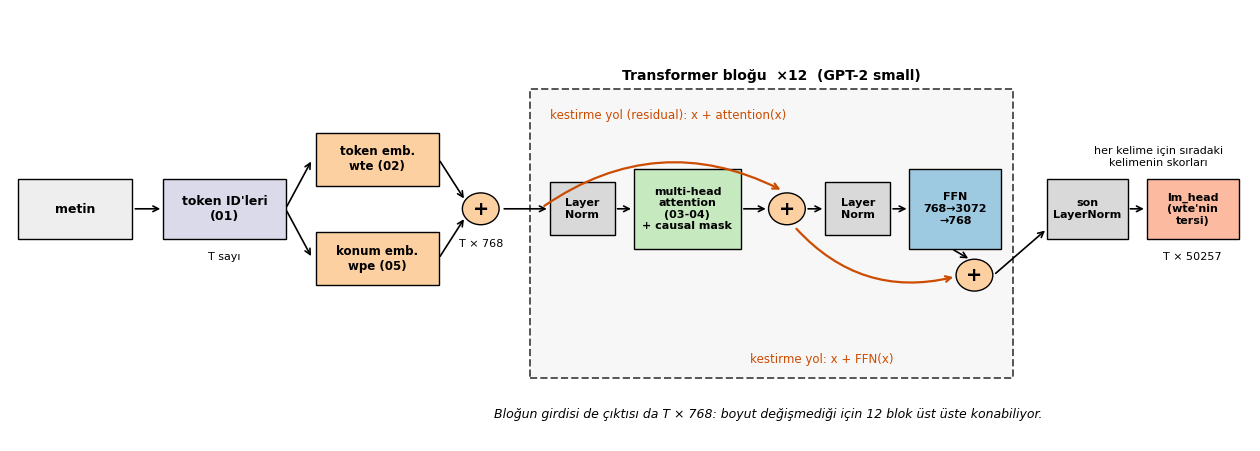

In [141]:
def draw_pipeline(save="transformer_pipeline.png"):
    fig, ax = plt.subplots(figsize=(16, 5.6))
    ax.set_xlim(0, 16.2); ax.set_ylim(-1.3, 5.2); ax.axis("off")

    def box(x, y, w, h, text, color, fs=9, weight="bold"):
        ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=color, edgecolor="black", lw=1.0))
        ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs, weight=weight)

    def arrow(x0, y0, x1, y1, lw=1.2):
        ax.annotate("", xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle="->", lw=lw))

    def plus(x, y):
        ax.add_patch(plt.Circle((x, y), 0.24, facecolor="#fdd0a2", edgecolor="black"))
        ax.text(x, y, "+", ha="center", va="center", fontsize=14, weight="bold")

    yc = 2.2   # ana çizgi
    # girdi tarafı
    box(0.1, yc - 0.45, 1.5, 0.9, "metin", "#eeeeee")
    box(2.0, yc - 0.45, 1.6, 0.9, "token ID'leri\n(01)", "#dadaeb")
    ax.text(2.8, yc - 0.65, "T sayı", ha="center", va="top", fontsize=8)
    box(4.0, yc + 0.35, 1.6, 0.8, "token emb.\nwte (02)", "#fdd0a2", fs=8.5)
    box(4.0, yc - 1.15, 1.6, 0.8, "konum emb.\nwpe (05)", "#fdd0a2", fs=8.5)
    plus(6.15, yc)
    ax.text(6.15, yc - 0.45, "T × 768", ha="center", va="top", fontsize=8)
    arrow(1.6, yc, 2.0, yc); arrow(3.6, yc, 3.95, yc + 0.75); arrow(3.6, yc, 3.95, yc - 0.75)
    arrow(5.6, yc + 0.75, 5.95, yc + 0.12); arrow(5.6, yc - 0.75, 5.95, yc - 0.12)

    # blok
    bx0, bx1 = 6.8, 13.1
    ax.add_patch(plt.Rectangle((bx0, -0.35), bx1 - bx0, 4.35, facecolor="#f7f7f7", edgecolor="#555555", lw=1.4, linestyle="--"))
    ax.text((bx0 + bx1) / 2, 4.15, "Transformer bloğu  ×12  (GPT-2 small)", ha="center", fontsize=10, weight="bold")
    arrow(6.42, yc, 7.05, yc)

    # 1. alt parça: LN -> attention -> +
    box(7.05, yc - 0.4, 0.85, 0.8, "Layer\nNorm", "#d9d9d9", fs=8)
    box(8.15, yc - 0.6, 1.4, 1.2, "multi-head\nattention\n(03-04)\n+ causal mask", "#c7e9c0", fs=8)
    plus(10.15, yc)
    arrow(7.9, yc, 8.15, yc); arrow(9.55, yc, 9.91, yc)
    ax.annotate("", xy=(10.1, yc + 0.27), xytext=(6.95, yc + 0.02),
                arrowprops=dict(arrowstyle="->", lw=1.6, color="#cc4c02", connectionstyle="arc3,rad=-0.3"))
    ax.text(8.6, 3.55, "kestirme yol (residual): x + attention(x)", ha="center", fontsize=8.5, color="#cc4c02")

    # 2. alt parça: LN -> FFN -> +
    box(10.65, yc - 0.4, 0.85, 0.8, "Layer\nNorm", "#d9d9d9", fs=8)
    box(11.75, yc - 0.6, 1.2, 1.2, "FFN\n768→3072\n→768", "#9ecae1", fs=8)
    plus(12.6, yc - 1.0)
    arrow(10.39, yc, 10.65, yc); arrow(11.5, yc, 11.75, yc)
    arrow(12.3, yc - 0.6, 12.55, yc - 0.77)
    ax.annotate("", xy=(12.36, yc - 1.02), xytext=(10.25, yc - 0.27),
                arrowprops=dict(arrowstyle="->", lw=1.6, color="#cc4c02", connectionstyle="arc3,rad=0.3"))
    ax.text(10.6, -0.12, "kestirme yol: x + FFN(x)", ha="center", fontsize=8.5, color="#cc4c02")

    # çıkış
    box(13.55, yc - 0.45, 1.05, 0.9, "son\nLayerNorm", "#d9d9d9", fs=8)
    box(14.85, yc - 0.45, 1.2, 0.9, "lm_head\n(wte'nin\ntersi)", "#fcbba1", fs=8)
    arrow(12.85, yc - 1.0, 13.55, yc - 0.3)
    arrow(14.6, yc, 14.85, yc)
    ax.text(15.45, yc - 0.65, "T × 50257", ha="center", va="top", fontsize=8)
    ax.text(15.0, yc + 0.65, "her kelime için sıradaki\nkelimenin skorları", ha="center", fontsize=8)

    ax.text(9.9, -0.95, "Bloğun girdisi de çıktısı da T × 768: boyut değişmediği için 12 blok üst üste konabiliyor.",
            ha="center", fontsize=9, style="italic")
    plt.savefig(save, dpi=130, bbox_inches="tight")
    plt.show()

draw_pipeline()

**Önemli nokta:** Bloğun girdisi de çıktısı da `T × 768`. Boyut değişmediği için aynı bloğu 12 kez üst üste koymak mümkün. GPT-2 small'da 12 blok var, GPT-2 medium'da 24, GPT-3'te 96. Büyük modeller esasen **daha çok blok ve daha geniş vektörler**. Tasarım aynı.

Şema GPT-2'nin (ve bugünkü çoğu LLM'in) düzeni: **LayerNorm bir alt parçanın önünde** (`x + parça(LayerNorm(x))`). Orijinal Transformer ve BERT'te LayerNorm toplamadan **sonra** geliyor. Bunu Bölüm 8'de göreceğiz.

## 2) Modeli açalım: hangi parça ne kadar yer kaplıyor?

### Sezgi

Modelin ağırlıklarının hepsi üç türden: kelime tablosu (embedding), konum tablosu ve 12 bloğun içindeki matrisler. Kaç tane olduklarını sayıp "asıl yük nerede?" diye soralım.

Bir de HF'nin `hidden_states` çıktısı işimize yarayacak: `hs[0]` bloklara girmeden önceki vektörler, `hs[1]` 1. bloktan sonrası, ..., `hs[11]` 11. bloktan sonrası. **Dikkat:** `hs[12]` 12. bloktan sonra **ve son LayerNorm'dan sonra** geliyor.

In [142]:
metin = "The Eiffel Tower is located in the city of"
ids_eif = tok_gpt(metin, return_tensors="pt").input_ids          # (1, T)
toks_eif = [tok_gpt.decode(i) for i in ids_eif[0]]
out_eif = gpt(ids_eif, output_hidden_states=True, output_attentions=True)
hs_eif = out_eif.hidden_states                                    # 13 eleman: giriş + 12 blok çıkışı (sonuncusu ln_f sonrası)
print("token'lar:", toks_eif, "| T =", ids_eif.shape[1])
print("sıradaki kelime için en yüksek 5 tahmin:", [tok_gpt.decode(i) for i in out_eif.logits[0, -1].topk(5).indices])
print()

def n_param(m): return sum(p.numel() for p in m.parameters())
blk0 = tr_gpt.h[0]
toplam = n_param(gpt)
satirlar = [
    ("token embedding (wte)",   n_param(tr_gpt.wte)),
    ("konum embedding (wpe)",   n_param(tr_gpt.wpe)),
    ("1 blok: attention",       n_param(blk0.attn)),
    ("1 blok: FFN",             n_param(blk0.mlp)),
    ("1 blok: 2 LayerNorm",     n_param(blk0.ln_1) + n_param(blk0.ln_2)),
    ("12 blok toplamı",         12 * n_param(blk0)),
    ("son LayerNorm",           n_param(tr_gpt.ln_f)),
]
for ad, n in satirlar:
    print(f"{ad:26s} {n:>12,d}   %{100*n/toplam:5.1f}")
print(f"{'TOPLAM':26s} {toplam:>12,d}")
print("lm_head, wte ile aynı matrisi mi kullanıyor?", gpt.lm_head.weight is tr_gpt.wte.weight)
print(f"1 blokta FFN payı: %{100*n_param(blk0.mlp)/n_param(blk0):.1f}")

token'lar: ['The', ' E', 'iff', 'el', ' Tower', ' is', ' located', ' in', ' the', ' city', ' of'] | T = 11
sıradaki kelime için en yüksek 5 tahmin: [' Paris', ' London', ' Amsterdam', ' New', ' Berlin']

token embedding (wte)        38,597,376   % 31.0
konum embedding (wpe)           786,432   %  0.6
1 blok: attention             2,362,368   %  1.9
1 blok: FFN                   4,722,432   %  3.8
1 blok: 2 LayerNorm               3,072   %  0.0
12 blok toplamı              85,054,464   % 68.3
son LayerNorm                     1,536   %  0.0
TOPLAM                      124,439,808
lm_head, wte ile aynı matrisi mi kullanıyor? True
1 blokta FFN payı: %66.6


**Ne gördük?**

- Toplam **124,4 milyon** parametre. Bunun **38,6 milyonu (%31) sadece kelime tablosu** (50257 token × 768 sayı). Bloklar toplamı 85 milyon.
- Bir bloğun 7,09 milyon parametresinin **üçte ikisi FFN'de**, sadece üçte biri attention'da. Yani modelin "ağırlığının" çoğu attention'da değil, FFN'de. (Bu, FFN'in modelin bilgi depolayan kısmı olduğuna dair araştırmalara yol açtı; kaynaklara bak.)
- **Konum tablosu (`wpe`) sadece 0,79 milyon** (1024 konum × 768). GPT-2, 05'te gördüğümüz sinüs/kosinüs formülünü **kullanmıyor**: her konum için bir vektör var ve bunlar eğitimle **öğreniliyor**. 05'te "öğrenilebilir konum embedding'i" diye andığımız seçenek bu. Sonuç: GPT-2 en fazla 1024 token görebilir.
- `lm_head` (768 → 50257 dönüşümü) ayrı bir matris değil, **`wte`'nin aynısı ters yönde kullanılıyor**. Kelimeyi vektöre çeviren tablo, vektörü kelimeye çeviren tabloyla aynı. Ekstra 38 milyon parametre tasarrufu.

In [143]:
# Modelin girişinde gerçekten "kelime tablosu + konum tablosu" mu var? (hs[0] ile karşılaştır)
pos = torch.arange(ids_eif.shape[1])
x_giris = tr_gpt.wte(ids_eif[0]) + tr_gpt.wpe(pos)
print("wte[kelime] + wpe[konum]  ile  hs[0] arasındaki en büyük fark:", (x_giris - hs_eif[0][0]).abs().max().item())

wte[kelime] + wpe[konum]  ile  hs[0] arasındaki en büyük fark: 0.0


**Ne gördük?** Fark tam **0**. Modelin girişi, 05'te anlattığımız şey: **kelime vektörü + konum vektörü**. Tek fark konum vektörlerinin formülle değil eğitimle bulunmuş olması.

## 3) Attention'ı elle yeniden kuralım (blok 0)

### Sezgi

03 ve 04'te attention'ı `W_Q`, `W_K`, `W_V`, `W_O` matrisleriyle kurmuştuk. GPT-2'de bunlar nerede? HF'de `c_attn` diye **tek bir matris** var: boyutu `768 × 2304`. 2304 = 3 × 768. Yani Q, K, V matrislerinin yan yana yapıştırılmış hali. Tek çarpımla üçünü birden çıkarıp sonra üçe bölüyoruz. Sonra 04'teki tarif aynen:

1. 768 sayıyı **12 kafaya** böl (her kafa 64 sayı).
2. Her kafada `Q·K` skorları, `1/√64 = 1/8` ile ölçekle (03'teki `√d_k`), **causal mask** uygula, softmax.
3. Ağırlıkları V'ye uygula, kafaları yapıştır, `c_proj` (= 04'teki `W_O`) ile karıştır.

Yeni olan tek şey **causal mask**: bir kelimenin **sağındaki** kelimelere dikkat skoru `-sonsuz` yapılıyor, softmax'tan sonra 0 oluyor. (Egzersiz 3 ve 5'te 03/04'te bunu zaten yapmıştık.)

Aşağıda GPT-2'nin bloğunu kendi kodumuzla yazıyoruz. HF'nin kodunu kullanmıyoruz, sadece **ağırlıklarını** alıyoruz.

In [144]:
N_HEAD, D_MODEL, D_HEAD = 12, 768, 64

def ln_manual(x, ln_layer):
    """LayerNorm: her kelimenin 768 sayısını ortalama 0, yayılım 1 yap, sonra öğrenilmiş ölçek (g) ve kayma (b) uygula."""
    mu = x.mean(-1, keepdim=True)
    var = ((x - mu) ** 2).mean(-1, keepdim=True)
    return (x - mu) / torch.sqrt(var + ln_layer.eps) * ln_layer.weight + ln_layer.bias

def attn_manual(x, blk):
    """GPT-2 attention'ı. x: (T, 768), zaten LayerNorm'dan geçmiş. Dönüş: (çıktı (T,768), ağırlıklar (12,T,T))."""
    T = x.shape[0]
    qkv = x @ blk.attn.c_attn.weight + blk.attn.c_attn.bias            # (T, 2304): Q, K, V yan yana
    q, k, v = qkv.split(D_MODEL, dim=-1)
    q, k, v = [t.view(T, N_HEAD, D_HEAD).transpose(0, 1) for t in (q, k, v)]   # (12, T, 64): 12 kafa
    skor = q @ k.transpose(-1, -2) / math.sqrt(D_HEAD)                  # (12, T, T)
    gorunur = torch.tril(torch.ones(T, T, dtype=torch.bool))            # alt üçgen: kelime sadece solunu görür
    skor = skor.masked_fill(~gorunur, float("-inf"))
    w = torch.softmax(skor, dim=-1)
    o = (w @ v).transpose(0, 1).reshape(T, D_MODEL)                     # kafaları yapıştır
    return o @ blk.attn.c_proj.weight + blk.attn.c_proj.bias, w         # c_proj = 04'teki W_O

x0 = hs_eif[0][0]                                                       # bloklara giren vektörler (T, 768)
a0, w0 = attn_manual(ln_manual(x0, blk0.ln_1), blk0)
print("c_attn matrisinin şekli:", tuple(blk0.attn.c_attn.weight.shape), "(= 768 x 3*768)")
print("bizim ağırlıklar ile GPT-2'nin attention ağırlıkları arasındaki en büyük fark:",
      (w0 - out_eif.attentions[0][0]).abs().max().item())

c_attn matrisinin şekli: (768, 2304) (= 768 x 3*768)
bizim ağırlıklar ile GPT-2'nin attention ağırlıkları arasındaki en büyük fark: 5.960464477539062e-07


**Ne gördük?** Bizim yazdığımız attention, GPT-2'nin blok 0 attention ağırlıklarıyla **3e-7 farkla** aynı sonucu veriyor (bu, float32 yuvarlama hatası). 03-04'te kurduğumuz mekanizma gerçekten GPT-2'nin içindeki mekanizma. Fark sadece ölçek: 12 kafa, kafa başı 64 sayı.

Şimdi bu ağırlıklara bakalım. Blok 0'ın ilk 4 kafası, cümlemizde her kelimenin hangi kelimelere baktığı:

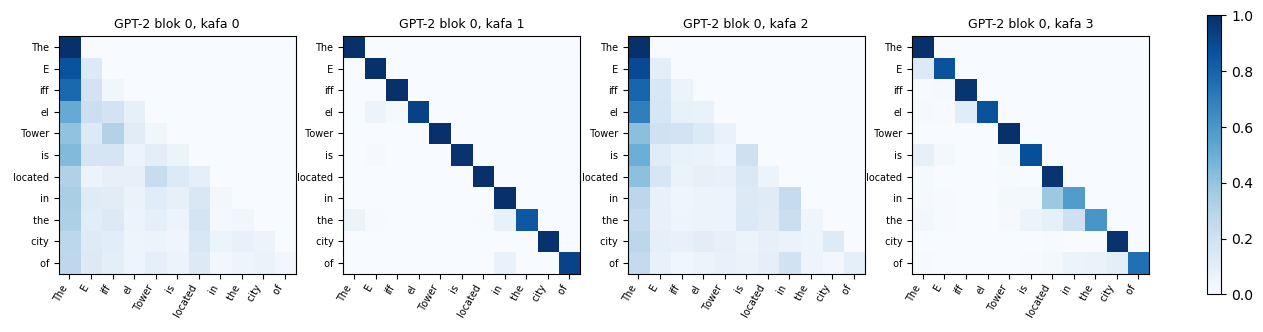

Üst üçgendeki (sağdaki kelimelere) toplam ağırlık, 4 kafa için: [0.0, 0.0, 0.0, 0.0]


In [145]:
def plot_attn(ax, w, toks, title):
    """w: (T, T) dikkat ağırlıkları. Satır = bakan kelime, sütun = bakılan kelime."""
    im = ax.imshow(w, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(toks))); ax.set_yticks(range(len(toks)))
    ax.set_xticklabels(toks, rotation=60, ha="right", fontsize=7)
    ax.set_yticklabels(toks, fontsize=7)
    ax.set_title(title, fontsize=9)
    return im

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for h, ax in enumerate(axes):
    im = plot_attn(ax, out_eif.attentions[0][0][h], toks_eif, f"GPT-2 blok 0, kafa {h}")
fig.colorbar(im, ax=axes, fraction=0.012)
plt.savefig("gpt2_causal_heads.png", dpi=130, bbox_inches="tight")
plt.show()
print("Üst üçgendeki (sağdaki kelimelere) toplam ağırlık, 4 kafa için:",
      [round(float(torch.triu(out_eif.attentions[0][0][h], diagonal=1).sum()), 6) for h in range(4)])

**Ne gördük?**

- **Üst üçgen tamamen 0** (yazdırdığımız toplam 0.0): kelime sağındakilere hiç bakmıyor. Bu, causal mask.
- **Kafalar farklı iş görüyor** (04'te "kafalar özelleşir" demiştik). Blok 0'da kafa 0 ve 2, hemen hemen her kelimeyi **ilk kelimeye** (`The`) yönlendiriyor. Kafa 1 ve 3 ise ağırlıklı olarak **kelimenin kendisine** bakıyor (köşegen); kafa 3'te `in` ve `the` biraz da bir önceki kelimeye bakıyor.
- Her satır toplamı 1 (softmax), ama kaç kelimeye dağıldığı satırdan satıra değişiyor: ilk satırın seçeneği yok (sadece kendisi), son satırın 11 seçeneği var.

## 4) Causal mask: GPT-2 ile BERT'i ayıran tek kural

### Sezgi

GPT-2 **sıradaki kelimeyi tahmin etmek** için eğitildi. Eğitim sırasında modele "The cat sat on the" verip "mat"i tahmin ettiriyoruz. Ama verimli olmak için bunu **cümlenin her konumu için aynı anda** yapıyoruz: 6 kelimelik bir cümlede 6 tahmin birden. Her konum sadece kendinden öncekileri görmeli, yoksa cevabı doğrudan okur ve hiçbir şey öğrenmez. İşte causal mask'in nedeni bu.

BERT ise başka bir oyunla eğitildi: cümledeki bazı kelimeleri `[MASK]` ile gizle, **iki taraftaki** kelimelere bakarak tahmin et. Orada herkes herkesi görebilir (mask yok).

Bunu basit bir deneyle ayırt edelim: **cümlenin son kelimesini değiştirelim** (`mat` → `sofa`) ve önceki kelimelerin çıkış vektörleri değişiyor mu diye bakalım.

In [146]:
s1_gpt = tok_gpt("The cat sat on the mat", return_tensors="pt").input_ids
s2_gpt = tok_gpt("The cat sat on the sofa", return_tensors="pt").input_ids
h1 = gpt(s1_gpt, output_hidden_states=True).hidden_states[-1][0]
h2 = gpt(s2_gpt, output_hidden_states=True).hidden_states[-1][0]
print("GPT-2 token'ları:", [tok_gpt.decode(i) for i in s2_gpt[0]])
print("GPT-2: her konumun çıkış vektöründeki değişim:", (h1 - h2).norm(dim=-1).numpy().round(3))

s1_bert = tok_bert("the cat sat on the mat", return_tensors="pt")
s2_bert = tok_bert("the cat sat on the sofa", return_tensors="pt")
g1 = bert.bert(**s1_bert).last_hidden_state[0]
g2 = bert.bert(**s2_bert).last_hidden_state[0]
print("BERT token'ları :", tok_bert.convert_ids_to_tokens(s2_bert.input_ids[0]))
print("BERT : her konumun çıkış vektöründeki değişim:", (g1 - g2).norm(dim=-1).numpy().round(3))

GPT-2 token'ları: ['The', ' cat', ' sat', ' on', ' the', ' sofa']
GPT-2: her konumun çıkış vektöründeki değişim: [ 0.     0.     0.     0.     0.    28.286]
BERT token'ları : ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'sofa', '[SEP]']
BERT : her konumun çıkış vektöründeki değişim: [ 3.428  4.385  5.128  4.329  6.314  8.504 12.275  2.592]


**Ne gördük?**

- **GPT-2:** İlk 5 konumun (`The cat sat on the`) çıkış vektörü **birebir aynı** (fark 0). Sadece son konum değişti. Bir kelime, sağındaki kelimeler değişse bile **hiç etkilenmiyor**.
- **BERT:** Son kelimeyi değiştirince **her konumun** vektörü değişti, `[CLS]` ve `[SEP]` dahil. BERT'te her kelime tüm cümleye bakıyor.

Bu farkın pratik bir sonucu var: GPT-2'de önceki kelimelerin vektörleri bir daha değişmediği için, metin üretirken onları **hesaplayıp saklayabiliriz** (buna "KV cache" deniyor, 08'de göreceğiz). BERT'te yeni bir kelime gelince hepsini baştan hesaplamak gerekir. Uzun bağlamlı modellerin maliyet tartışması (tez konusu #10) büyük ölçüde bu mekanizmanın etrafında dönüyor.

Aynı cümleyi iki modele verip dikkat haritalarını yan yana koyalım:

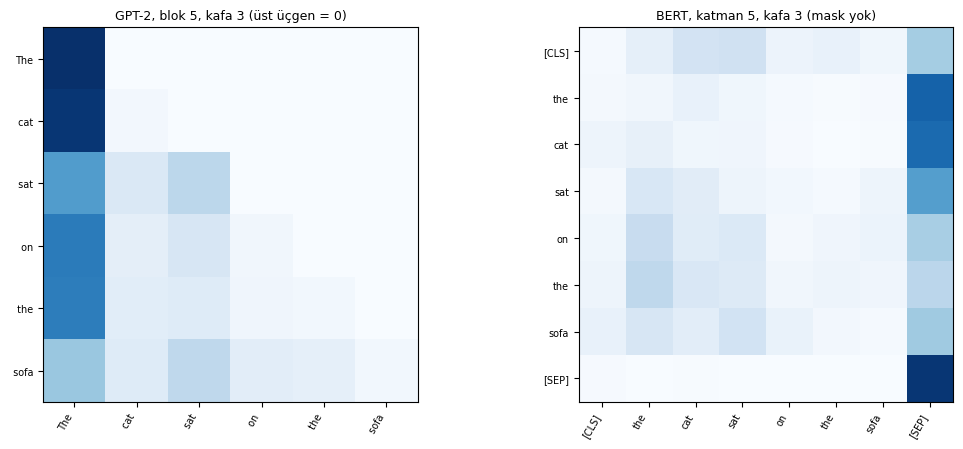

In [147]:
out_s2g = gpt(s2_gpt, output_attentions=True)
out_s2b = bert.bert(**s2_bert, output_attentions=True)
toks_g = [tok_gpt.decode(i) for i in s2_gpt[0]]
toks_b = tok_bert.convert_ids_to_tokens(s2_bert.input_ids[0])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
plot_attn(axes[0], out_s2g.attentions[5][0][3], toks_g, "GPT-2, blok 5, kafa 3 (üst üçgen = 0)")
plot_attn(axes[1], out_s2b.attentions[5][0][3], toks_b, "BERT, katman 5, kafa 3 (mask yok)")
plt.tight_layout(); plt.savefig("causal_vs_bidirectional.png", dpi=130, bbox_inches="tight"); plt.show()

**Ne gördük?** Soldaki GPT-2 haritasının **üst üçgeni tamamen beyaz**: kelime sağına bakamıyor. Sağdaki BERT haritasında ise üst üçgen de dolu: kelimeler sağdakilere de bakabiliyor (bu kafada çoğu kelimenin dikkati `[SEP]` üstünde toplanmış, tek tek kafaların böyle alışkanlıkları olabiliyor). Kodda tek fark `masked_fill` satırı.

## 5) FFN: kelimeler arası değil, kelime başına düşünmek

### Sezgi

Attention'dan sonra her kelimenin elinde "çevresinden topladığı bilgi" var. FFN her kelimeye **aynı küçük ağı ayrı ayrı** uyguluyor:

> 768 sayı → **3072'ye genişlet** → GELU (yumuşak bir "aç/kapa" fonksiyonu, ReLU'nun yumuşatılmış hali) → 768'e geri **sıkıştır**

Genişletmek, bilgiyi daha fazla "köşeye" yayıp ayrı ayrı işleme fırsatı veriyor. Kelimeler arası hiçbir alışveriş yok: 5. kelimenin FFN çıktısı sadece 5. kelimenin girdisine bağlı. Bunu deneyle doğrulayalım: kelimeleri karıştır, FFN'den geçir, çıktıyı geri sırala. Kelimeler birbirini etkilemiyorsa sonuç aynı çıkmalı.

In [148]:
def gelu_manual(x):
    """GPT-2'nin kullandığı GELU (tanh yaklaşımı)."""
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * x ** 3)))

def mlp_manual(x, blk):
    """FFN: 768 -> 3072 -> GELU -> 768. x: (T, 768)."""
    gizli = gelu_manual(x @ blk.mlp.c_fc.weight + blk.mlp.c_fc.bias)     # (T, 3072)
    return gizli @ blk.mlp.c_proj.weight + blk.mlp.c_proj.bias           # (T, 768)

# 1) bizim FFN, GPT-2'nin FFN'i ile aynı mı? (blok 3, gerçek girdi)
blk3 = tr_gpt.h[3]
x3 = hs_eif[3][0]                                       # 3. bloğa giren vektörler
girdi_ffn = ln_manual(x3, blk3.ln_2)
print("bizim FFN ile GPT-2'nin FFN'i arasındaki fark:", (mlp_manual(girdi_ffn, blk3) - blk3.mlp(girdi_ffn)).abs().max().item())

# 2) karıştır -> FFN -> geri sırala
perm = torch.randperm(x3.shape[0], generator=torch.Generator().manual_seed(0))
normal = mlp_manual(girdi_ffn, blk3)
karisik = mlp_manual(girdi_ffn[perm], blk3)
print("kelimeleri karıştırıp FFN'den geçirince, geri sıralanmış çıktı farkı:", (normal[perm] - karisik).abs().max().item())

bizim FFN ile GPT-2'nin FFN'i arasındaki fark: 6.103515625e-05
kelimeleri karıştırıp FFN'den geçirince, geri sıralanmış çıktı farkı: 0.0


**Ne gördük?**

- Bizim FFN, GPT-2'nin FFN'iyle aynı sonucu veriyor (fark ~1e-5, float yuvarlaması).
- Kelimeleri karıştırıp FFN'e verince çıktılar **sadece karışıyor**, değerleri değişmiyor (fark 0). FFN her kelimeye tek başına bakıyor.

İşbölümü şöyle: **attention = kelimeler arası iletişim, FFN = kelime içi hesaplama.** Bir blokta ikisi sırayla çalışıyor ve 12 blokta bu iletişim + hesaplama döngüsü 12 kez tekrarlanıyor.

## 6) Residual + LayerNorm: bilginin kaybolmaması ve sayıların taşmaması

### Sezgi

12 bloğu üst üste koyunca iki risk var:

1. **Bilgi kaybolabilir.** Her blok vektörü tamamen yeniden yazsa, ilk bloktaki bilgi 12 dönüşümden sağ çıkamaz. Çözüm: bloklar vektörü **yeniden yazmıyor, üstüne ekleme yapıyor**: `x_yeni = x + parça(x)`. Eldeki vektör bir **otoban** gibi bloklardan geçiyor, her blok sadece küçük bir düzeltme ekliyor. Buna **residual stream** (artık akışı) da deniyor.
2. **Sayılar kontrolden çıkabilir.** Sürekli eklemeyle vektörlerin boyu büyür, bazı sayılar ötekilerden çok büyüklenir. **LayerNorm** her kelimenin 768 sayısını ortalama 0, yayılım 1 olacak şekilde yeniden ölçekler, sonra öğrenilmiş bir ölçek ve kayma uygular.

Önce LayerNorm'un ne yaptığına bakalım, sonra bloklar boyunca vektörün nasıl değiştiğini ölçelim.

In [149]:
v = hs_eif[3][0][2]                                  # 3. bloğun girdisinden bir kelimenin 768 sayısı
z = (v - v.mean()) / torch.sqrt(((v - v.mean()) ** 2).mean() + tr_gpt.h[0].ln_1.eps)   # LayerNorm'un ilk adımı (g ve b'den önce)
print(f"önce  : ortalama {v.mean():+.3f}, std {v.std(unbiased=False):.3f}, en büyük |sayı| {v.abs().max():.2f}")
print(f"sonra : ortalama {z.mean():+.3f}, std {z.std(unbiased=False):.3f}, en büyük |sayı| {z.abs().max():.2f}")

# vektör boyları (norm) ve her bloğun eklediği düzeltmenin göreli büyüklüğü
norm = torch.stack([hs_eif[i][0].norm(dim=-1) for i in range(12)])           # (12, T): giriş + ilk 11 blok çıkışı
print("\nbloklar boyunca vektör boyu (norm):")
print("  ilk kelime :", norm[[0, 1, 4, 11], 0].numpy().round(0), "(giriş, blok 1, blok 4, blok 11 çıkışı)")
print("  diğerleri  :", norm[[0, 1, 4, 11], 1:].mean(dim=1).numpy().round(0), "(ortalama)")

önce  : ortalama +0.027, std 2.121, en büyük |sayı| 20.12
sonra : ortalama +0.000, std 1.000, en büyük |sayı| 9.50

bloklar boyunca vektör boyu (norm):
  ilk kelime : [  10.  133. 2748. 3112.] (giriş, blok 1, blok 4, blok 11 çıkışı)
  diğerleri  : [  5.  56.  67. 247.] (ortalama)


**Ne gördük?**

- LayerNorm sonrası ortalama 0, std 1: sayılar kontrol altında. (Sonra öğrenilmiş `g` ve `b` ile yeniden ölçekleniyor.)
- **Vektör boyu bloklarla büyüyor** (ilk kelime dışındakilerde ortalama 5 → 56 → 67 → 247). Her blok üstüne ekleme yaptığı için normal. Bu yüzden her alt parçanın **önünde** bir LayerNorm var: parçalar hep aynı ölçekte girdi görüyor.
- **Tuhaf olan ilk kelime:** vektör boyu 10 → 133 → 2748 → 3112. Diğer kelimelerden **onlarca kat büyük**. GPT-2 ilk token'ın vektöründe çok büyük sayılar biriktiriyor ve dikkatin çoğunu ona yönlendirebiliyor (literatürde "attention sink" ve "massive activations" olarak geçiyor; kaynaklara bak). Bu bir hata değil, eğitimle ortaya çıkan bir alışkanlık. Sonuçları bu notebook'un kapsamı dışında ama uzun bağlam tartışması için önemli bir ipucu.

Şimdi otoban fikrini doğrudan sınayalım: **bir bloğu tamamen atlarsak** (`x` olduğu gibi geçsin) model ne yapıyor? Kendi `forward`'umuzu yazıp yapalım.

In [150]:
def block_manual(x, blk):
    """Tam bir GPT-2 bloğu. x: (T, 768). LayerNorm alt parçanın ÖNÜNDE (pre-LN), toplama sonra."""
    a, _ = attn_manual(ln_manual(x, blk.ln_1), blk)
    x = x + a                                             # kestirme yol 1: x + attention
    return x + mlp_manual(ln_manual(x, blk.ln_2), blk)    # kestirme yol 2: x + FFN

def forward_manual(ids_1d, skip=()):
    """Bütün model: giriş embedding'i -> 12 blok -> son LayerNorm -> lm_head. skip: atlanacak blok numaraları."""
    x = tr_gpt.wte.weight[ids_1d] + tr_gpt.wpe.weight[: len(ids_1d)]
    for i, blk in enumerate(tr_gpt.h):
        if i in skip:
            continue
        x = block_manual(x, blk)
    return ln_manual(x, tr_gpt.ln_f) @ tr_gpt.wte.weight.T          # lm_head = wte'nin tersi

# önce doğruluk kontrolü: blok blok, sonra logit'ler
x = hs_eif[0][0]
for i in range(11):
    x = block_manual(x, tr_gpt.h[i])
    print(f"blok {i:2d} çıkışı ile GPT-2 arasındaki fark: {(x - hs_eif[i+1][0]).abs().max().item():.1e}")
lg = forward_manual(ids_eif[0])
print("\nlogit farkı (bütün model):", (lg - out_eif.logits[0]).abs().max().item())
print("bizim tahmin :", [tok_gpt.decode(i) for i in lg[-1].topk(5).indices])
print("GPT-2 tahmini:", [tok_gpt.decode(i) for i in out_eif.logits[0, -1].topk(5).indices])

blok  0 çıkışı ile GPT-2 arasındaki fark: 4.6e-05
blok  1 çıkışı ile GPT-2 arasındaki fark: 6.1e-05
blok  2 çıkışı ile GPT-2 arasındaki fark: 2.4e-04
blok  3 çıkışı ile GPT-2 arasındaki fark: 2.4e-04
blok  4 çıkışı ile GPT-2 arasındaki fark: 2.4e-04
blok  5 çıkışı ile GPT-2 arasındaki fark: 2.4e-04
blok  6 çıkışı ile GPT-2 arasındaki fark: 2.4e-04
blok  7 çıkışı ile GPT-2 arasındaki fark: 2.4e-04
blok  8 çıkışı ile GPT-2 arasındaki fark: 2.4e-04
blok  9 çıkışı ile GPT-2 arasındaki fark: 2.4e-04
blok 10 çıkışı ile GPT-2 arasındaki fark: 2.4e-04

logit farkı (bütün model): 0.0001373291015625
bizim tahmin : [' Paris', ' London', ' Amsterdam', ' New', ' Berlin']
GPT-2 tahmini: [' Paris', ' London', ' Amsterdam', ' New', ' Berlin']


**Ne gördük?** Kendi yazdığımız ~30 satırlık kod, GPT-2'nin bütün bloklarını ve sonunda logit'lerini yeniden üretiyor. Blok çıkışlarındaki fark en fazla 2,4e-4, logit farkı 6e-5 (12 blok boyunca biriken float32 yuvarlama hatası, gerçek bir fark değil). Tahmin listesi de birebir aynı. Yani **GPT-2 small tam olarak Bölüm 1'deki şema.** Ekstra sır yok.

In [151]:
for atla in [(), (5,), (11,), (0,), (3, 4, 5, 6)]:
    l = forward_manual(ids_eif[0], skip=atla)[-1]
    print(f"atlanan bloklar {str(atla):14s} -> ilk 3 tahmin: {[tok_gpt.decode(i) for i in l.topk(3).indices]}")

atlanan bloklar ()             -> ilk 3 tahmin: [' Paris', ' London', ' Amsterdam']
atlanan bloklar (5,)           -> ilk 3 tahmin: [' Paris', ' London', ' New']
atlanan bloklar (11,)          -> ilk 3 tahmin: [' Paris', ' London', ' Amsterdam']
atlanan bloklar (0,)           -> ilk 3 tahmin: ['.', ' and', ',']
atlanan bloklar (3, 4, 5, 6)   -> ilk 3 tahmin: [' the', ' London', ' E']


**Ne gördük?**

- **Blok 5 ya da blok 11'i** atınca model hâlâ `Paris` diyor. Otoban fikri işliyor: her blok küçük bir düzeltme eklediği için biri eksik olunca akış bozulmuyor.
- **Blok 0'ı** atınca tahminler noktalama işaretine dönüşüyor (`.`, `and`, `,`). İlk blok "sıradan bir düzeltme" değil: az önce gördüğümüz ilk-kelime vektörünün devasa boyuta çıkışı gibi hazırlıkları orada yapılıyor (bu, bu tek örnekten gördüğümüz bir gözlem; genelleme için Egzersiz 3'te daha çok cümleyle sınayacağız).
- **Ortadaki 4 bloğu (3-6) birden** atınca `Paris` artık ilk üçe girmiyor (`the`, `London`, `E`), ama çıktılar hâlâ okunabilir kelimeler. Blok 0'ı atmak kadar yıkıcı değil.

Bir de LayerNorm'un yeri hakkında not: GPT-2'de LayerNorm alt parçanın **önünde**. BERT'te ve orijinal Transformer'da **toplamadan sonra**. Bunu BERT'in bir katmanında doğrulayalım.

In [152]:
kat0 = bert.bert.encoder.layer[0]
emb_b = bert.bert.embeddings(s1_bert.input_ids)                     # (1, T, 768)
ctx = kat0.attention.self(emb_b)[0]                                 # attention'ın ham çıktısı
# post-LN tarifi: LayerNorm( dense(ctx) + girdi )   -> LayerNorm TOPLAMADAN SONRA
bizim = ln_manual(kat0.attention.output.dense(ctx) + emb_b, kat0.attention.output.LayerNorm)
print("BERT attention alt parçası, post-LN tarifimizle modülün çıktısı arasındaki fark:",
      (bizim - kat0.attention.output(ctx, emb_b)).abs().max().item())
print("BERT LayerNorm eps:", kat0.attention.output.LayerNorm.eps, "| GPT-2 LayerNorm eps:", tr_gpt.h[0].ln_1.eps)

BERT attention alt parçası, post-LN tarifimizle modülün çıktısı arasındaki fark: 1.9073486328125e-06
BERT LayerNorm eps: 1e-12 | GPT-2 LayerNorm eps: 1e-05


**Ne gördük?** BERT'te tarif `LayerNorm(x + parça(x))` (post-LN): fark ~4e-6 (float yuvarlaması), yani düzen gerçekten öyle. GPT-2'de `x + parça(LayerNorm(x))` (pre-LN). Bu küçük yer değişikliği önemli: pre-LN, çok katmanlı modellerin eğitimini daha kararlı yapıyor, bu yüzden GPT-2'den sonra çoğu büyük model pre-LN'e geçti (Xiong ve arkadaşlarının makalesi, kaynaklarda). Eps değerinin farklı olması ise ayrıntı.

## 7) Üç aile: encoder-only, decoder-only, encoder-decoder

### Sezgi

Şimdi elimizde hem GPT-2'nin (Bölüm 4-6) hem BERT'in çalışan bir parçası var. Hepsi aynı legodan yapılmış. Fark, **kimin kimi görebildiği** ve dolayısıyla modelin ne için eğitildiği:

| Aile | Örnek | Kim kimi görür? | Doğal görev |
|---|---|---|---|
| **Encoder-only** | BERT | herkes herkesi (mask yok) | cümleyi **anlamak**: sınıflandırma, boşluk doldurma, embedding çıkarma |
| **Decoder-only** | GPT-2, GPT-3/4, Llama | herkes sadece solunu (causal mask) | metin **üretmek**: bugünkü LLM'ler |
| **Encoder-decoder** | orijinal Transformer, T5 | encoder: herkes herkesi. Decoder: sadece solunu **ve ayrıca** encoder'ın çıktısına bakar (cross-attention) | bir metni **başka bir metne çevirmek**: çeviri, özet |

Encoder-decoder'ın decoder'ında bloğa üçüncü bir alt parça ekleniyor: **cross-attention**. Attention'ın aynısı, ama Q decoder'dan, K ve V encoder'ın çıktısından geliyor: "üretirken kaynak cümlenin neresine bakayım?"

Aşağıda üç ailenin "kim kimi görür" tablosunu (mask'i) çizelim:

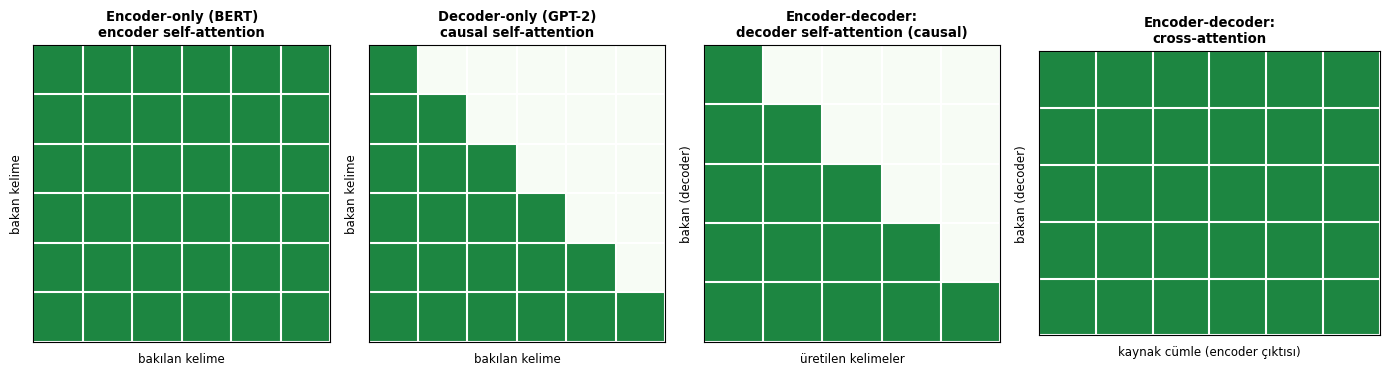

In [153]:
def draw_families(save="architecture_families.png"):
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.8), gridspec_kw=dict(width_ratios=[1, 1, 1, 1.15]))
    def show(ax, M, title, xl, yl):
        ax.imshow(M, cmap="Greens", vmin=0, vmax=1.3)
        ax.set_xticks(range(M.shape[1])); ax.set_yticks(range(M.shape[0]))
        ax.set_xticklabels([]); ax.set_yticklabels([])
        ax.set_xticks(np.arange(-.5, M.shape[1], 1), minor=True); ax.set_yticks(np.arange(-.5, M.shape[0], 1), minor=True)
        ax.grid(which="minor", color="white", lw=1.5); ax.tick_params(which="both", length=0)
        ax.set_title(title, fontsize=9.5, weight="bold"); ax.set_xlabel(xl, fontsize=8.5); ax.set_ylabel(yl, fontsize=8.5)
    show(axes[0], np.ones((6, 6)), "Encoder-only (BERT)\nencoder self-attention", "bakılan kelime", "bakan kelime")
    show(axes[1], np.tril(np.ones((6, 6))), "Decoder-only (GPT-2)\ncausal self-attention", "bakılan kelime", "bakan kelime")
    show(axes[2], np.tril(np.ones((5, 5))), "Encoder-decoder:\ndecoder self-attention (causal)", "üretilen kelimeler", "bakan (decoder)")
    show(axes[3], np.ones((5, 6)), "Encoder-decoder:\ncross-attention", "kaynak cümle (encoder çıktısı)", "bakan (decoder)")
    plt.tight_layout(); plt.savefig(save, dpi=130, bbox_inches="tight"); plt.show()

draw_families()

**Ne gördük?** Yeşil hücre = "bakabilir". Encoder-only'de tüm tablo yeşil. Decoder-only'de sadece alt üçgen. Encoder-decoder'da decoder'ın kendi içi alt üçgen, ama ayrıca kaynak cümleye **tam** bakabildiği dikdörtgen bir cross-attention tablosu var.

Şimdi bu farkın kullanıma yansımasını görelim. Boşluk doldurmada BERT sağ ve solu birlikte kullanıyor. GPT-2 ise sadece soldan devam edebiliyor:

In [154]:
def bert_bosluk(cumle, k=5):
    """BERT ile [MASK]'i doldur: sağ ve sol bağlam birlikte kullanılır."""
    enc = tok_bert(cumle, return_tensors="pt")
    yer = (enc.input_ids[0] == tok_bert.mask_token_id).nonzero()[0, 0]
    return [tok_bert.decode(i) for i in bert(**enc).logits[0, yer].topk(k).indices]

def gpt_devam(onek, k=5):
    """GPT-2 ile sadece soldaki bağlamdan sıradaki kelimeyi tahmin et."""
    ids = tok_gpt(onek, return_tensors="pt").input_ids
    return [tok_gpt.decode(i) for i in gpt(ids).logits[0, -1].topk(k).indices]

print("BERT  :", bert_bosluk("the capital of france is [MASK]."))
print("GPT-2 :", gpt_devam("The capital of France is"))
print()
print("BERT  (sağ bağlam 'bread'):", bert_bosluk("i walked to the [MASK] to buy some bread."))
print("BERT  (sağ bağlam 'books'):", bert_bosluk("i walked to the [MASK] to buy some books."))
print("GPT-2 ('i walked to the'   ):", gpt_devam("I walked to the"))

BERT  : ['paris', 'lille', 'lyon', 'marseille', 'tours']
GPT-2 : [' the', ' now', ' a', ' France', ' Paris']

BERT  (sağ bağlam 'bread'): ['market', 'bakery', 'store', 'kitchen', 'shop']
BERT  (sağ bağlam 'books'): ['store', 'bookstore', 'library', 'mall', 'shop']
GPT-2 ('i walked to the'   ): [' front', ' door', ' back', ' entrance', ' house']


**Ne gördük?** Sağ bağlamı değiştirince (`bread` → `books`) BERT'in boşluk tahminleri değişiyor: sağı görüyor. GPT-2'nin ise böyle bir imkânı yok: "I walked to the" öneğinden sonra gelecek kelimeyi tahmin ederken cümlenin devamını hiç bilmiyor. Bu yüzden boşluk doldurmada BERT, üretimde GPT-2 doğal seçim. Modern LLM'ler (ChatGPT, Claude, Llama...) decoder-only: tek bir "sıradaki kelime" görevi hem sohbeti hem çeviriyi hem kodu kapsayacak kadar genel çıktı (07'de bunu konuşacağız).

Son olarak encoder-decoder'ın bir örneğine kısaca bakalım: T5-small. Çeviri yapıyor ve decoder bloğunda **üç** alt parça var. (İsteğe bağlı bölüm; T5-small ~240 MB indirir.)

In [155]:
from transformers import T5ForConditionalGeneration, T5Tokenizer
tok_t5 = T5Tokenizer.from_pretrained("t5-small")
t5 = T5ForConditionalGeneration.from_pretrained("t5-small", attn_implementation="eager").eval()

blok_t5 = t5.decoder.block[0]
print("T5 decoder bloğunun alt parçaları:", [type(m).__name__ for m in blok_t5.layer])
print("BERT encoder katmanı parametre sayısı:", n_param(bert.bert.encoder.layer[0]), "| GPT-2 bloğu:", n_param(blk0),
      "| T5-small decoder bloğu:", n_param(blok_t5))

girdi = tok_t5("translate English to German: The house is wonderful.", return_tensors="pt").input_ids
cikti = t5.generate(girdi, max_new_tokens=30, num_beams=1, do_sample=False)
print("T5 çeviri:", tok_t5.decode(cikti[0], skip_special_tokens=True))

T5 decoder bloğunun alt parçaları: ['T5LayerSelfAttention', 'T5LayerCrossAttention', 'T5LayerFF']
BERT encoder katmanı parametre sayısı: 7087872 | GPT-2 bloğu: 7087872 | T5-small decoder bloğu: 4196096
T5 çeviri: Das Haus ist wunderbar.


In [156]:
model_name = "t5-small"  # veya "t5-base"
tok_t5 = T5Tokenizer.from_pretrained(model_name)
t5 = T5ForConditionalGeneration.from_pretrained(model_name, attn_implementation="eager").eval()

# Örnek olarak bir almanca-ingilizce çeviri yapalım.
input_text = "translate English to French: My mother is a nurse."
# Kelime tablosu ve konum tablosunu kullanarak giriş token ID'lerini alalım.
input_ids = tok_t5(input_text, return_tensors="pt").input_ids
# T5 modelini kullanarak çeviri yapalım.
output_ids = t5.generate(input_ids, max_new_tokens=30, num_beams=1, do_sample=False)
# Çıktıyı çözümleyelim.
output_text = tok_t5.decode(output_ids[0], skip_special_tokens=True)
print("T5 çeviri:", output_text)

T5 çeviri: Ma mère est infirmière.


**Ne gördük?**

- T5'in decoder bloğunda `SelfAttention → CrossAttention → FF` diye **üç** alt parça var. Diğerlerinde iki. Cross-attention, encoder'ın çıktısına bakmak için eklenen parça.
- BERT katmanı ile GPT-2 bloğunun parametre sayısı **birebir aynı** (7.087.872): ikisi de 768 / 3072 boyutlu. Aileler arasındaki fark parça sayısında değil, **maskede ve düzende**. (T5-small daha küçük vektörler, 512 boyut, kullanıyor, o yüzden farklı.)
- T5-small kısa bir İngilizce cümleyi Almancaya çevirebiliyor. (Türkçe'ye çeviremez: bu modelin eğitiminde yok.)

## 8) Özet

- **Tam blok = attention + FFN + residual + LayerNorm.** Attention kelimeler arası bilgi taşır, FFN kelime başına hesap yapar. Bloğun ağırlığının üçte ikisi FFN'de.
- **Residual = otoban.** Her alt parça `x + parça(x)` ile üstüne düzeltme ekler. Bu yüzden 12 blok üst üste konabiliyor, tek bir bloğu atmak (0. hariç) modeli çökertmiyor.
- **GPT-2 small = 12 özdeş blok**, önünde kelime + (öğrenilmiş) konum tablosu, arkasında son LayerNorm ve tersine kullanılan kelime tablosu (`lm_head` = `wte`'nin tersi). Kendi yazdığımız kod logit'leri ~1e-4 farkla yeniden üretti.
- **Causal mask = decoder-only'nin kuralı.** GPT-2'de son kelimeyi değiştirince önceki konumlar hiç değişmedi, BERT'te hepsi değişti. Bu yüzden GPT-2 metin üretebiliyor ve KV cache mümkün.
- **Üç aile aynı legodan:** encoder-only (mask yok), decoder-only (causal mask), encoder-decoder (encoder + causal decoder + cross-attention). BERT katmanı ile GPT-2 bloğu aynı boyutta.
- **Tez bağlantısı:** #22 (hafif Transformer mimarileri + Türkçe) ve #21 (model küçültme) tam olarak bu blok anatomisi üzerinde oynuyor: kaç blok, kaç kafa, ne kadar genişlik. #10 (uzun bağlam vs RAG) için causal mask, KV cache ve ilk-token biriktirme gözlemi maliyetin nereden geldiğini anlatıyor. #23 (açıklanabilirlik) dikkat haritalarını (Bölüm 3-4) yorumlama girişimi.

## Egzersizler

Çözümler verilmiyor. Her egzersizin altında boş bir kod hücresi var. Her çözümde gerekirse kendi üretecini (`torch.Generator().manual_seed(...)`) o hücrenin içinde oluştur.

**Değişken adı uyarısı:** `gpt`, `bert`, `tr_gpt`, `tok_gpt`, `tok_bert`, `ids_eif`, `hs_eif`, `out_eif`, `blk0`, `x0`, `N_HEAD`, `D_MODEL`, `D_HEAD` ve fonksiyonlar (`ln_manual`, `attn_manual`, `mlp_manual`, `block_manual`, `forward_manual`, `plot_attn`, `n_param`) global. Egzersizlerde bunları **ezme** (`x_ex`, `loss_ex`, `w_ex` gibi farklı isimler kullan). 04'teki `h`/`d` sorununun aynısı.

Modeller `torch.set_grad_enabled(False)` ile çalışıyor; gradyan gerektiren bir şey yapmıyoruz.

### Egzersiz 1 — Model ne kadar büyür?

GPT-2 small: `d_model=768`, 12 blok, 12 kafa. GPT-2 medium: `d_model=1024`, 24 blok, 16 kafa.

(a) **Yazmadan önce tahmin et:** bir bloğun parametre sayısı yaklaşık `12 × d_model²` (attention `4 × d²`, FFN `8 × d²`). Bu tahminle small ve medium için bloklar toplamını hesapla.

(b) `GPT2LMHeadModel(GPT2Config(n_embd=..., n_layer=..., n_head=...))` ile rastgele ağırlıklı (indirme gerektirmeyen) bir medium kur ve gerçek parametre sayısını `n_param` ile bul. Tahminin gerçekten ne kadar uzak?

(c) Her iki modelde **embedding tablolarının** (wte + wpe) toplam içindeki payı ne? Model büyüdükçe bu pay neden düşüyor?

(d) Tahmindeki fark nereden geliyor? Bir bloğun içindeki parametreleri kalem kalem say (`blk0.named_parameters()`).

In [157]:
print("\n==== Egzersiz 1: Model Ne Kadar Büyür? ====")

# GPT-2 small modeli
vocab_size = tr_gpt.wte.weight.shape[0]  # Kelime haznesi boyutu (50.257)
d_model = tr_gpt.wte.weight.shape[1]     # Model boyutu (768)
layer_count = len(tr_gpt.h)              # Blok sayısı (12)
max_seq_len = tr_gpt.wpe.weight.shape[0] # Maksimum giriş uzunluğu (1024)



embedding_params = vocab_size * d_model  # Embedding parametre sayısı
positional_params = max_seq_len * d_model  # Konum embedding parametre sayısı
total_embedding_params = embedding_params + positional_params  # Toplam embedding parametre sayısı

multihead_attention_params = (3 * d_model * d_model) + (3 * d_model) + (d_model * d_model) + d_model  # Q, K, V ve çıkış projeksiyonu
ffn_params = (d_model * (4 * d_model) + (4 * d_model)) + ((4 * d_model) * d_model + d_model)  # FFN parametre sayısı (4*d_model = gizli boyutu)
block_ln = 2 * (d_model + d_model)  # Her blokta 2 LayerNorm, her biri d_model boyutunda
single_block_params = multihead_attention_params + ffn_params + block_ln  # Tek blok parametre sayısı

final_ln = 2 * d_model  # Son LayerNorm parametre sayısı

gpt2_small_params = total_embedding_params + (single_block_params * layer_count) + final_ln   # Toplam parametre sayısı

# GPT-2 medium modeli
vocab_size_medium = 50257  # Kelime haznesi boyutu (50.257)
d_model_medium = 1024      # Model boyutu (1024)
layer_count_medium = 24     # Blok sayısı (24)
max_seq_len_medium = 1024   # Maksimum giriş uzunluğu (1024)

embedding_params_medium = vocab_size_medium * d_model_medium  # Embedding parametre sayısı
positional_params_medium = max_seq_len_medium * d_model_medium  # Konum embedding parametre sayısı
total_embedding_params_medium = embedding_params_medium + positional_params_medium  # Toplam embedding parametre

multihead_attention_params_medium = (3 * d_model_medium * d_model_medium) + (3 * d_model_medium) + (d_model_medium * d_model_medium) + d_model_medium  # Q, K, V ve çıkış projeksiyonu
ffn_params_medium = (d_model_medium * (4 * d_model_medium) + (4 * d_model_medium)) + ((4 * d_model_medium) * d_model_medium + d_model_medium)  # FFN parametre sayısı (4*d_model = gizli boyutu)
block_ln_medium = 2 * (d_model_medium + d_model_medium)  # Her blokta 2 LayerNorm, her biri d_model boyutunda
single_block_params_medium = multihead_attention_params_medium + ffn_params_medium + block_ln_medium  # Tek blok parametre sayısı

final_ln_medium = 2 * d_model_medium  # Son LayerNorm parametre sayısı

gpt2_medium_params = total_embedding_params_medium + (single_block_params_medium * layer_count_medium) + final_ln_medium   # Toplam parametre sayısı


from transformers import GPT2LMHeadModel, GPT2Config

medium_model = GPT2LMHeadModel(GPT2Config(n_embd=d_model_medium, n_layer=layer_count_medium, n_head=16))
small_model = GPT2LMHeadModel(GPT2Config(n_embd=d_model, n_layer=12, n_head=12))

print(f"GPT-2 medium model parametre sayısı (Config): {sum(p.numel() for p in medium_model.parameters()):,}")
print(f"GPT-2 small model parametre sayısı (Config): {sum(p.numel() for p in small_model.parameters()):,}")
print(f"GPT-2 medium model parametre sayısı (Manuel): {gpt2_medium_params:,}")
print(f"GPT-2 small model parametre sayısı (Manuel): {gpt2_small_params:,}")

print("Manuel ile Config Hesaplama da WTE+WPE'in modele katkıları:")
manuel_wte_wpe_sum = embedding_params_medium + positional_params_medium
manuel_wte_wpe_overall = manuel_wte_wpe_sum / gpt2_medium_params * 100

config_wte_wpe_sum = n_param(medium_model.transformer.wte) + n_param(medium_model.transformer.wpe)
config_wte_wpe_overall = config_wte_wpe_sum / sum(p.numel() for p in medium_model.parameters()) * 100
print(f"WTE + WPE contribution to total parameters (manual): {manuel_wte_wpe_sum:,} ({manuel_wte_wpe_overall:.2f}%)")
print(f"WTE + WPE contribution to total parameters (Config): {config_wte_wpe_sum:,} ({config_wte_wpe_overall:.2f}%)")

print(f"WTE + WPE contribution to total parameters (GPT-2 small model): {n_param(small_model.transformer.wte) + n_param(small_model.transformer.wpe):,} ({(n_param(small_model.transformer.wte) + n_param(small_model.transformer.wpe)) / sum(p.numel() for p in small_model.parameters()) * 100:.2f}%)")
print(f"WTE + WPE contribution to total parameters (GPT-2 medium model): {n_param(medium_model.transformer.wte) + n_param(medium_model.transformer.wpe):,} ({(n_param(medium_model.transformer.wte) + n_param(medium_model.transformer.wpe)) / sum(p.numel() for p in medium_model.parameters()) * 100:.2f}%)")

print("Config'teki tüm parametreleri kalem kalem sayalım:")
all_params = medium_model.named_parameters()
for name, param in all_params:
    print(f"{name}: {param.numel():,} parameters")

print("\nYORUM: Yaptığımız tahminden farkımız yok")
print("\nYORUM: GPT-2 small modelinde WTE+WPE toplamı medium modele göre daha büyük bir yüzdeye sahip. Bu, küçük modellerde embedding katmanlarının toplam parametre sayısına daha fazla katkıda bulunduğunu gösteriyor.")


==== Egzersiz 1: Model Ne Kadar Büyür? ====
GPT-2 medium model parametre sayısı (Config): 354,823,168
GPT-2 small model parametre sayısı (Config): 124,439,808
GPT-2 medium model parametre sayısı (Manuel): 354,823,168
GPT-2 small model parametre sayısı (Manuel): 124,439,808
Manuel ile Config Hesaplama da WTE+WPE'in modele katkıları:
WTE + WPE contribution to total parameters (manual): 52,511,744 (14.80%)
WTE + WPE contribution to total parameters (Config): 52,511,744 (14.80%)
WTE + WPE contribution to total parameters (GPT-2 small model): 39,383,808 (31.65%)
WTE + WPE contribution to total parameters (GPT-2 medium model): 52,511,744 (14.80%)
Config'teki tüm parametreleri kalem kalem sayalım:
transformer.wte.weight: 51,463,168 parameters
transformer.wpe.weight: 1,048,576 parameters
transformer.h.0.ln_1.weight: 1,024 parameters
transformer.h.0.ln_1.bias: 1,024 parameters
transformer.h.0.attn.c_attn.weight: 3,145,728 parameters
transformer.h.0.attn.c_attn.bias: 3,072 parameters
transforme

### Egzersiz 2 — Attention mı FFN mi daha çok yazıyor?

Residual stream'e her blok iki ekleme yapıyor: bir attention'dan, bir FFN'den. `block_manual`'ı parçalayarak (`attn_manual`, `mlp_manual`, `ln_manual`'ı ayrı ayrı çağırarak) her blok için şunu ölç:

- `||attention'ın eklediği|| / ||o andaki x||` ve `||FFN'in eklediği|| / ||o andaki x||` (kelime başına, sonra kelimeler üzerinden ortalama; **ilk kelimeyi ortalamadan çıkar**, Bölüm 6'daki sebeple).

(a) 3 farklı cümle için 12 blokta iki eğriyi çiz. Hangi blokta hangisi baskın?

(b) İkisinin toplamı, `hs_eif`'ten hesaplanan toplam güncellemeyle (`hs[i+1] - hs[i]`) tutarlı mı? (Dikkat: `hs[12]` son LayerNorm sonrası, onu karşılaştırmaya katma.)

(c) Kendi cümlelerinle: son blokta güncellemeler neden bu kadar büyük olabilir?


==== Egzersiz 2: Attention mı FFN mi Daha Çok Yazıyor? ====

Cümle: 'The cat sat on the mat.'
Blok  | Attention oranı  | FFN oranı 
0     | 5.6673           | 6.2919    
1     | 0.1890           | 0.1919    
2     | 0.1581           | 0.2154    
3     | 0.1210           | 0.2059    
4     | 0.1265           | 0.2147    
5     | 0.1247           | 0.2376    
6     | 0.1147           | 0.2594    
7     | 0.1100           | 0.2712    
8     | 0.1064           | 0.2960    
9     | 0.1022           | 0.3465    
10    | 0.0951           | 0.6227    
11    | 0.6794           | 0.4416    
Tutarlılık kontrolü (blok 0-10): en büyük fark 2.4e-04  ->  TUTARLI


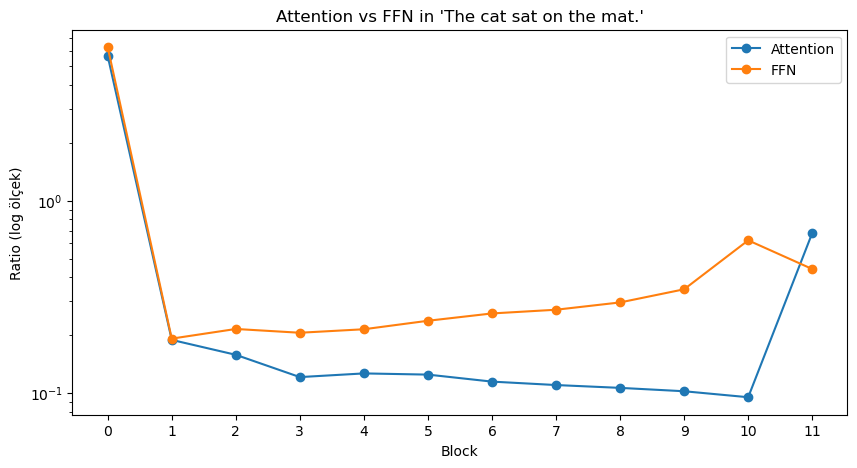


Cümle: 'The dog barked loudly.'
Blok  | Attention oranı  | FFN oranı 
0     | 5.9312           | 5.7782    
1     | 0.1854           | 0.1912    
2     | 0.1245           | 0.2098    
3     | 0.1258           | 0.2211    
4     | 0.1137           | 0.2032    
5     | 0.1033           | 0.2204    
6     | 0.0995           | 0.2305    
7     | 0.0921           | 0.2403    
8     | 0.1054           | 0.2571    
9     | 0.1012           | 0.2787    
10    | 0.1304           | 0.5706    
11    | 0.7711           | 0.3878    
Tutarlılık kontrolü (blok 0-10): en büyük fark 2.4e-04  ->  TUTARLI


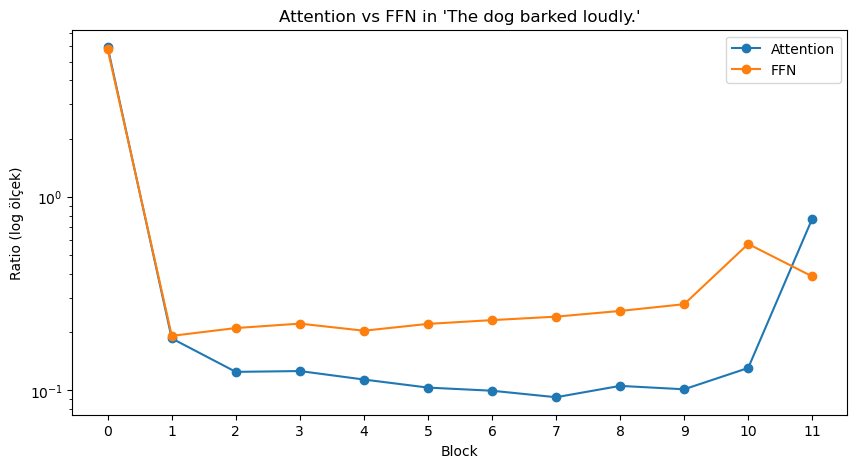


Cümle: 'The sun is shining brightly.'
Blok  | Attention oranı  | FFN oranı 
0     | 5.5944           | 6.5076    
1     | 0.1788           | 0.1900    
2     | 0.1224           | 0.2036    
3     | 0.1321           | 0.1910    
4     | 0.1393           | 0.1929    
5     | 0.1090           | 0.2141    
6     | 0.1201           | 0.2469    
7     | 0.1325           | 0.2539    
8     | 0.1103           | 0.2506    
9     | 0.1524           | 0.3092    
10    | 0.1131           | 0.6091    
11    | 0.7069           | 0.5885    
Tutarlılık kontrolü (blok 0-10): en büyük fark 2.4e-04  ->  TUTARLI


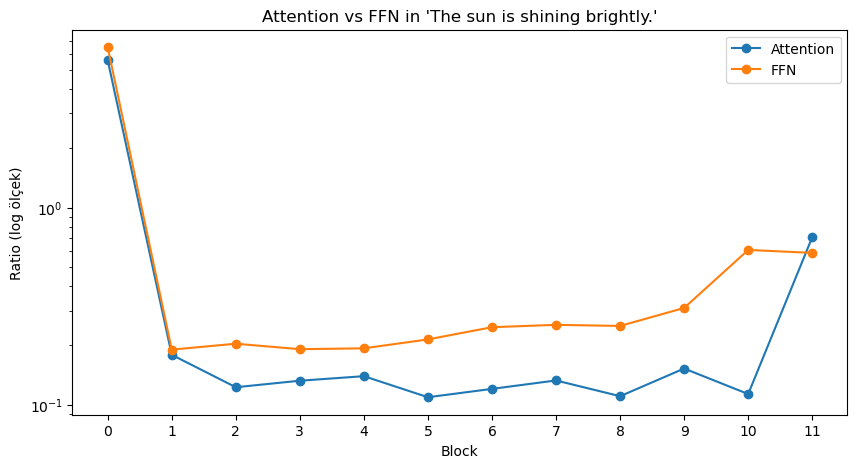


YORUM (x ekseni cümledeki konum değil, BLOK numarası):
1) (b) Tutarlılık: (attention + FFN) eklemesi GPT-2'nin blok değişimiyle ~2e-4 farkla aynı. Fark float yuvarlaması. Kod doğru.
2) Blok 0: iki oran da 5-6, sonraki bloklarda 0.1-0.3. Nedeni bir ölçek etkisi: bloğa girerken akışta sadece kelime+konum embedding'i var ve normu ~5 (Bölüm 6). Bloğun eklediği bu küçük vektöre göre çok büyük. Akış büyüdükçe aynı büyüklükteki ekleme oransal olarak küçülüyor. Bu 'modeller ilk token'lara çok bakıyor' anlamına gelmez.
3) Blok 1-10: FFN'in eklediği kısım attention'ınkinden büyük (yaklaşık 1 ile 6 kat arası; ör. blok 6: FFN 0.23-0.26, attention 0.10-0.12). Attention'ın eklediği kısım bu bloklarda neredeyse düz (~0.1-0.19). FFN blok 10'da 0.57-0.62'ye sıçrıyor.
4) Blok 11 (son blok): üç cümlede de attention oranı (0.68-0.77) FFN'i geçiyor ve blok 1-10'a göre 5-7 kat sıçrıyor. FFN de blok 11'de büyüyor (0.39-0.59).
5) (c) Hipotez (ölçmedik): son bloğun çıktısı hemen ln_f + wte'nin tersiyle 'sırad

In [158]:
print("\n==== Egzersiz 2: Attention mı FFN mi Daha Çok Yazıyor? ====")

sentences = [
    "The cat sat on the mat.",
    "The dog barked loudly.",
    "The sun is shining brightly.",
]

# block_manual'ı parçalayıp her adımı ayrı çalıştırıyoruz. Bu sefer her cümle için tek bir döngü var:
# aynı döngüde hem oranları hesaplıyor, hem GPT-2 ile tutarlılığı kontrol ediyor, sonra çiziyoruz.
for sentence in sentences:
    ids_ex2 = tok_gpt(sentence, return_tensors="pt").input_ids                 # (1, T)
    hs_ex2 = gpt(ids_ex2, output_hidden_states=True).hidden_states             # GPT-2'nin kendi blok çıkışları (sadece kontrol için)
    x = tr_gpt.wte.weight[ids_ex2[0]] + tr_gpt.wpe.weight[: ids_ex2.shape[1]]  # bloklara giren vektörler

    attention_ratios = []   # her cümle için sıfırdan başlıyor (önceki cümleden kalma değer yok)
    ffn_ratios = []
    max_fark = 0.0

    print(f"\nCümle: '{sentence}'")
    print(f"{'Blok':<5} | {'Attention oranı':<16} | {'FFN oranı':<10}")
    for i, blk in enumerate(tr_gpt.h):
        x_base_norm = x.norm(dim=-1)  # bloğa girerken x'in normu (paydada hep bu)

        # Attention adımı
        a, _ = attn_manual(ln_manual(x, blk.ln_1), blk)
        x_after_attention = x + a                      # kestirme yol 1: x + attention

        # FFN adımı
        ffn_output = mlp_manual(ln_manual(x_after_attention, blk.ln_2), blk)
        x_after_ffn = x_after_attention + ffn_output   # kestirme yol 2: x + FFN

        # (b) tutarlılık: (attention + FFN) eklemesi = GPT-2'nin bu bloktaki toplam değişimi mi?
        # hs[12] son LayerNorm'dan sonra geldiği için sadece blok 0-10'a bakıyoruz.
        if i < 11:
            gpt2_fark = hs_ex2[i + 1][0] - hs_ex2[i][0]
            max_fark = max(max_fark, ((a + ffn_output) - gpt2_fark).abs().max().item())

        x = x_after_ffn   # bir sonraki blok için güncelle (bu satır olmazsa her blok ham embedding'e uygulanır)

        # ilk kelime (indeks 0) ortalamadan çıkarıldı: normu diğerlerinden çok farklı (Bölüm 6)
        attn_ratio_val = (a.norm(dim=-1)[1:] / x_base_norm[1:]).mean().item()
        ffn_ratio_val = (ffn_output.norm(dim=-1)[1:] / x_base_norm[1:]).mean().item()
        attention_ratios.append(attn_ratio_val)
        ffn_ratios.append(ffn_ratio_val)
        print(f"{i:<5} | {attn_ratio_val:<16.4f} | {ffn_ratio_val:<10.4f}")

    print(f"Tutarlılık kontrolü (blok 0-10): en büyük fark {max_fark:.1e}  ->  {'TUTARLI' if max_fark < 1e-3 else 'TUTARSIZ'}")

    plt.figure(figsize=(10, 5))
    plt.plot(attention_ratios, marker="o", label="Attention")
    plt.plot(ffn_ratios, marker="o", label="FFN")
    plt.yscale("log")   # blok 0 diğerlerinden ~30 kat büyük; log ölçekte hepsi okunur
    plt.xticks(range(12))
    plt.xlabel("Block")
    plt.ylabel("Ratio (log ölçek)")
    plt.title(f"Attention vs FFN in '{sentence}'")
    plt.legend()
    plt.show()

print('\nYORUM (x ekseni cümledeki konum değil, BLOK numarası):')
print("1) (b) Tutarlılık: (attention + FFN) eklemesi GPT-2'nin blok değişimiyle ~2e-4 farkla aynı. Fark float yuvarlaması. Kod doğru.")
print("2) Blok 0: iki oran da 5-6, sonraki bloklarda 0.1-0.3. Nedeni bir ölçek etkisi: bloğa girerken akışta sadece kelime+konum embedding'i var ve normu ~5 (Bölüm 6). Bloğun eklediği bu küçük vektöre göre çok büyük. Akış büyüdükçe aynı büyüklükteki ekleme oransal olarak küçülüyor. Bu 'modeller ilk token'lara çok bakıyor' anlamına gelmez.")
print("3) Blok 1-10: FFN'in eklediği kısım attention'ınkinden büyük (yaklaşık 1 ile 6 kat arası; ör. blok 6: FFN 0.23-0.26, attention 0.10-0.12). Attention'ın eklediği kısım bu bloklarda neredeyse düz (~0.1-0.19). FFN blok 10'da 0.57-0.62'ye sıçrıyor.")
print("4) Blok 11 (son blok): üç cümlede de attention oranı (0.68-0.77) FFN'i geçiyor ve blok 1-10'a göre 5-7 kat sıçrıyor. FFN de blok 11'de büyüyor (0.39-0.59).")
print("5) (c) Hipotez (ölçmedik): son bloğun çıktısı hemen ln_f + wte'nin tersiyle 'sıradaki kelime' skorlarına çevriliyor. Akışı bu tahmine hazır hale getirmek için son blokun büyük bir yeniden yazım yapması makul.")

### Egzersiz 3 — Hangi blok vazgeçilmez?

`forward_manual(ids, skip=(i,))` ile her bloğu **tek tek** atlayıp modelin kalitesini ölç. Kalite ölçüsü: bir cümlede her konumdaki "sıradaki gerçek token"ın ortalama negatif log-olasılığı (cross-entropy, `logits[:-1]` ile `ids[1:]` arasında).

(a) En az 5 farklı İngilizce cümle seç (10+ token). 12 blok için ortalama kaybı çiz. Atlamasız kayıp çizgisini de ekle.

(b) En kritik 3 blok hangileri? Bölüm 6'daki tek cümlelik gözlemle uyuşuyor mu?

(c) En az zarar veren blok hangisi? Bu blok "gereksiz" mi? Kısa bir yorum yaz. (İpucu: bloğu atmak ile bloğu yeniden eğitmek aynı şey değil.)

(d) İsteğe bağlı: Bloğun sadece **attention** kısmını ya da sadece **FFN** kısmını atlayan bir varyant yaz. Hangisinin atlanması daha çok zarar veriyor?


==== Egzersiz 3: Hangi Blok Vazgeçilmez? ====

Baz kayıp (hiçbir blok atlanmadan): 3.612

En kritik 3 blok (en yüksek kayıp artışı):
  blok  0: Δkayıp = +4.596
  blok 11: Δkayıp = +0.419
  blok  8: Δkayıp = +0.131
4. ve 5. sıra (üçüncüden ne kadar farklı?):
  blok 10: Δkayıp = +0.127
  blok  6: Δkayıp = +0.120

En az zarar veren 3 blok (en düşük kayıp artışı):
  blok  4: Δkayıp = -0.054
  blok  2: Δkayıp = +0.007
  blok  5: Δkayıp = +0.013


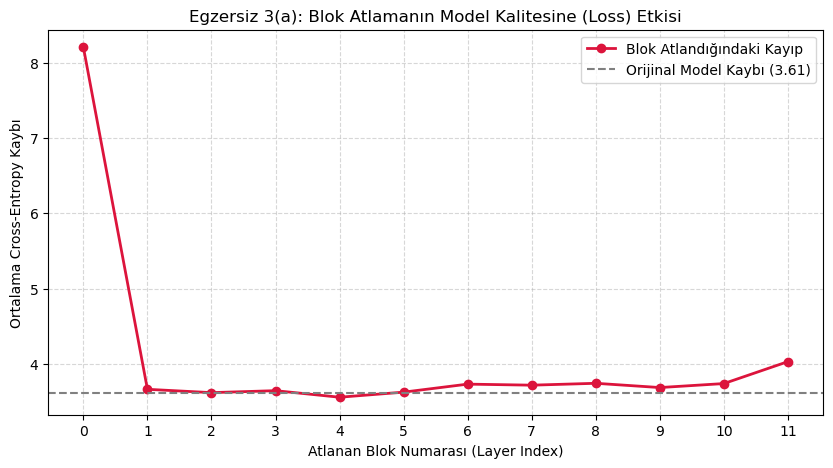


YORUM:
1) Blok 0 atlanınca kayıp +4.6 artıyor (3.6 -> 8.2). Bu diğer her şeyden yaklaşık 10 kat büyük. İkinci sırada blok 11 var (+0.42). Net olan: en kritik iki blok 0 ve 11.
2) Üçüncü sıra blok 8 (+0.13), ama 4. (blok 10: +0.127) ve 5. (blok 6: +0.120) ile arasındaki fark gürültü düzeyinde. 5 cümleyle üçüncüyü güvenle söyleyemem.
3) (c) En az zarar veren: blok 4 (-0.05, atlayınca kayıp baz çizgisinin biraz ALTINA iniyor), blok 2 ve 5 (~0). Bu 'blok gereksiz' demek değil: fark 5 cümlelik gürültü içinde, ve bir bloğu atmak ile o blok olmadan model eğitmek aynı şey değil (diğer 11 blok o bloğun varlığına göre öğrendi). Ayrıca orta blokları tek tek atmak zararsız görünüyor ama Bölüm 6'da 3-6. blokları birlikte atınca 'Paris' ilk üçten düşmüştü.


In [159]:
print("\n==== Egzersiz 3: Hangi Blok Vazgeçilmez? ====")

import torch.nn.functional as F

sentences_ex3 = [
    "The mysterious old library at the corner of the street contains many forgotten secrets.",
    "Artificial intelligence is rapidly changing the way modern software engineers write code every day.",
    "Walking through the dense forest during the autumn season brings an incredible sense of peace.",
    "Scientists discovered a fascinating new planet that might support human life in the future.",
    "A well-balanced diet combined with regular exercise is essential for maintaining good long-term health.",
]

all_sentence_losses = []
original_baseline_losses = []

# Her bloğu atlayıp modelin kalitesini ölçeceğiz.
for sentence in sentences_ex3:
    ids = tok_gpt(sentence, return_tensors="pt").input_ids[0]
    original_output = forward_manual(ids)
    orig_loss = F.cross_entropy(original_output[:-1], ids[1:], reduction="mean").item()
    original_baseline_losses.append(orig_loss)

    sentence_block_losses = []

    for skip_block in range(12):
        output_skip = forward_manual(ids, skip=(skip_block,))
        skip_loss = F.cross_entropy(output_skip[:-1], ids[1:], reduction="mean").item()
        sentence_block_losses.append(skip_loss)

    all_sentence_losses.append(sentence_block_losses)

# 12 blok için ortalama kaybı (5 cümle üzerinden) atlamasız kayıp çizgisiyle çizeceğiz.
avg_block_losses = np.mean(all_sentence_losses, axis=0)
avg_original_loss = np.mean(original_baseline_losses)
delta_ex3 = avg_block_losses - avg_original_loss     # bloğu atlayınca kaybın baz kayıptan farkı

print(f"\nBaz kayıp (hiçbir blok atlanmadan): {avg_original_loss:.3f}")
print("\nEn kritik 3 blok (en yüksek kayıp artışı):")
for b in np.argsort(delta_ex3)[::-1][:3]:
    print(f"  blok {b:2d}: Δkayıp = {delta_ex3[b]:+.3f}")
print("4. ve 5. sıra (üçüncüden ne kadar farklı?):")
for b in np.argsort(delta_ex3)[::-1][3:5]:
    print(f"  blok {b:2d}: Δkayıp = {delta_ex3[b]:+.3f}")
print("\nEn az zarar veren 3 blok (en düşük kayıp artışı):")
for b in np.argsort(delta_ex3)[:3]:
    print(f"  blok {b:2d}: Δkayıp = {delta_ex3[b]:+.3f}")

# Grafiği Çizme
plt.figure(figsize=(10, 5))
plt.plot(range(12), avg_block_losses, marker='o', color='crimson', label='Blok Atlandığındaki Kayıp', linewidth=2)
plt.axhline(y=avg_original_loss, color='gray', linestyle='--', label=f'Orijinal Model Kaybı ({avg_original_loss:.2f})')

plt.xticks(range(12))
plt.xlabel('Atlanan Blok Numarası (Layer Index)')
plt.ylabel('Ortalama Cross-Entropy Kaybı')
plt.title('Egzersiz 3(a): Blok Atlamanın Model Kalitesine (Loss) Etkisi')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print('\nYORUM:')
print('1) Blok 0 atlanınca kayıp +4.6 artıyor (3.6 -> 8.2). Bu diğer her şeyden yaklaşık 10 kat büyük. İkinci sırada blok 11 var (+0.42). Net olan: en kritik iki blok 0 ve 11.')
print('2) Üçüncü sıra blok 8 (+0.13), ama 4. (blok 10: +0.127) ve 5. (blok 6: +0.120) ile arasındaki fark gürültü düzeyinde. 5 cümleyle üçüncüyü güvenle söyleyemem.')
print("3) (c) En az zarar veren: blok 4 (-0.05, atlayınca kayıp baz çizgisinin biraz ALTINA iniyor), blok 2 ve 5 (~0). Bu 'blok gereksiz' demek değil: fark 5 cümlelik gürültü içinde, ve bir bloğu atmak ile o blok olmadan model eğitmek aynı şey değil (diğer 11 blok o bloğun varlığına göre öğrendi). Ayrıca orta blokları tek tek atmak zararsız görünüyor ama Bölüm 6'da 3-6. blokları birlikte atınca 'Paris' ilk üçten düşmüştü.")

In [165]:
print("\n==== Egzersiz 3d: İsteğe Bağlı — Sadece Attention ya da Sadece FFN Atlamak ====")

# Bölüm 6'daki forward_manual'a dokunmamak için ayrı isimli bir fonksiyon: her bloğun attention ve FFN kısmı ayrı ayrı atlanabiliyor.
def forward_ablate(ids, skip_attn=(), skip_ffn=()):
    x = tr_gpt.wte.weight[ids] + tr_gpt.wpe.weight[: len(ids)]
    for i, blk in enumerate(tr_gpt.h):
        if i not in skip_attn:      # atlanırsa sadece kestirme yol kalır (x aynen geçer)
            attn_out, _ = attn_manual(ln_manual(x, blk.ln_1), blk)
            x = x + attn_out
        if i not in skip_ffn:
            x = x + mlp_manual(ln_manual(x, blk.ln_2), blk)
    return ln_manual(x, tr_gpt.ln_f) @ tr_gpt.wte.weight.T

sentences_ex3d = [
    "The quick brown fox jumps over the lazy dog.",
    "In a galaxy far, far away, an epic battle unfolds between the forces of good and evil.",
    "The art of programming is a blend of logic, creativity, and problem-solving skills.",
]

num_blocks = len(tr_gpt.h)
attn_delta_losses = torch.zeros(num_blocks)
ffn_delta_losses = torch.zeros(num_blocks)
baseline_losses = []

for sentence in sentences_ex3d:
    ids = tok_gpt(sentence, return_tensors="pt").input_ids[0]
    baseline_loss = F.cross_entropy(forward_ablate(ids)[:-1], ids[1:], reduction="mean").item()
    baseline_losses.append(baseline_loss)

    for block_idx in range(num_blocks):
        loss_skip_attn = F.cross_entropy(forward_ablate(ids, skip_attn=(block_idx,))[:-1], ids[1:], reduction="mean").item()
        attn_delta_losses[block_idx] += (loss_skip_attn - baseline_loss)

        loss_skip_ffn = F.cross_entropy(forward_ablate(ids, skip_ffn=(block_idx,))[:-1], ids[1:], reduction="mean").item()
        ffn_delta_losses[block_idx] += (loss_skip_ffn - baseline_loss)

n_sent = len(sentences_ex3d)
avg_orig_loss = sum(baseline_losses) / n_sent
attn_delta_losses /= n_sent
ffn_delta_losses /= n_sent

print(f"Ortalama Baz Kayıp (Baseline Loss): {avg_orig_loss:.4f}\n")
print(f"{'Blok':<6} | {'ΔLoss (Skip Attn)':<18} | {'ΔLoss (Skip FFN)':<18} | {'Baskın Hasar'}")
print("-" * 62)

for i in range(num_blocks):
    d_attn = attn_delta_losses[i].item()
    d_ffn = ffn_delta_losses[i].item()

    if abs(d_attn - d_ffn) <= 0.10:
        dominant = "Benzer / Nötr (±0.1)"
    elif d_attn > d_ffn:
        dominant = "Attention daha kritik"
    else:
        dominant = "FFN daha kritik"

    print(f"{i:<6} | {d_attn:>+16.4f}  | {d_ffn:>+16.4f}  | {dominant}")

print(f"\nBlok 0 hariç ortalama ΔLoss  ->  Attention: {attn_delta_losses[1:].mean().item():+.4f} | FFN: {ffn_delta_losses[1:].mean().item():+.4f}")
print('\nYORUM (3 cümle, ±0.1 eşiği gürültü düzeyi, kesin sonuç değil):')
print('1) Blok 0: attention atmak +2.56, FFN atmak +2.47. İkisinden biri eksik olsa model çöküyor. Blok 0 için ikisi de gerekli.')
print("2) Blok 0 hariç ortalama ΔLoss: attention +0.045, FFN +0.112. FFN'i atmak ortalamada ~2.5 kat daha çok zarar veriyor, ama eşiği aşan sadece iki blok var (5 ve 10, ikisi de FFN).")
print("3) Blok 10: FFN atınca +0.30, attention atınca ~0. E2'de FFN oranı da tam bu blokta sıçrıyordu (0.57-0.62). Bu blokta FFN hem büyük ekleme yapıyor hem de atılınca hasar veriyor.")
print("4) Blok 11: E2'de attention'ın eklediği kısım FFN'inkinden büyüktü (0.68-0.77'ye karşı 0.39-0.59), ama atılınca hasar FFN'de biraz daha yüksek (+0.24 ve +0.19). Yani eklemenin büyüklüğü ile atılınca oluşan hasar aynı şey değil.")


==== Egzersiz 3d: İsteğe Bağlı — Sadece Attention ya da Sadece FFN Atlamak ====
Ortalama Baz Kayıp (Baseline Loss): 3.3546

Blok   | ΔLoss (Skip Attn)  | ΔLoss (Skip FFN)   | Baskın Hasar
--------------------------------------------------------------
0      |          +2.5575  |          +2.4673  | Benzer / Nötr (±0.1)
1      |          +0.0448  |          -0.0121  | Benzer / Nötr (±0.1)
2      |          -0.0384  |          +0.0496  | Benzer / Nötr (±0.1)
3      |          -0.0001  |          +0.0823  | Benzer / Nötr (±0.1)
4      |          +0.0297  |          +0.0754  | Benzer / Nötr (±0.1)
5      |          +0.0245  |          +0.1314  | FFN daha kritik
6      |          +0.0560  |          +0.0976  | Benzer / Nötr (±0.1)
7      |          +0.0573  |          +0.1102  | Benzer / Nötr (±0.1)
8      |          +0.1073  |          +0.0952  | Benzer / Nötr (±0.1)
9      |          +0.0336  |          +0.0656  | Benzer / Nötr (±0.1)
10     |          -0.0145  |          +0.2977  | FFN 

### Egzersiz 4 — Türkçe'nin token maliyeti (01'e dönüş)

GPT-2 İngilizce ağırlıklı bir veriyle eğitildi. Aynı anlama gelen 5 İngilizce-Türkçe cümle çifti yaz (örn. `"Ankara is the capital of Turkey."` / `"Ankara Türkiye'nin başkentidir."`).

(a) Her çift için token sayılarını ve Türkçe/İngilizce oranını yaz. 01'de BPE ile bulduğun eğilimle uyuşuyor mu?

(b) `gpt(ids, labels=ids).loss` ile her cümlenin token başına ortalama kaybını bul. Türkçe için kayıp daha mı yüksek?

(c) **Cümle başına toplam kayıp** (= token başına kayıp × tahmin edilen token sayısı) hesapla. (b)'deki kıyas neden adil değil? Adil bir kıyas için ne ölçmek gerekir?

(d) Bu, GPT-2'yi Türkçe bir tez konusunda (#15, #22, #12) doğrudan kullanmaya dair ne söylüyor?


==== Egzersiz 4: Türkçe'nin Token Maliyeti ====

--- (a) Token Sayıları ve Oranları ---
Cümle    | TR Token   | EN Token   | Oran (TR/EN)
----------------------------------------------
Cümle 1   | 16         | 9          | 1.78x
Cümle 2   | 22         | 9          | 2.44x
Cümle 3   | 24         | 10         | 2.40x
Cümle 4   | 29         | 10         | 2.90x
Cümle 5   | 30         | 9          | 3.33x
----------------------------------------------
Ortalama | 24.2       | 9.4        | 2.57x

--- Cümle Başına Toplam Kayıp (Kayıp x (T-1)) ---
Cümle 1:
  TR Toplam: 77.0980 (Ort: 5.1399/tok, T=16)
  EN Toplam: 27.5192 (Ort: 3.4399/tok, T=9)
Cümle 2:
  TR Toplam: 87.7747 (Ort: 4.1797/tok, T=22)
  EN Toplam: 24.8773 (Ort: 3.1097/tok, T=9)
Cümle 3:
  TR Toplam: 125.9944 (Ort: 5.4780/tok, T=24)
  EN Toplam: 38.1421 (Ort: 4.2380/tok, T=10)
Cümle 4:
  TR Toplam: 157.3100 (Ort: 5.6182/tok, T=29)
  EN Toplam: 30.3340 (Ort: 3.3704/tok, T=10)
Cümle 5:
  TR Toplam: 139.8864 (Ort: 4.8237/tok, T=30)
  

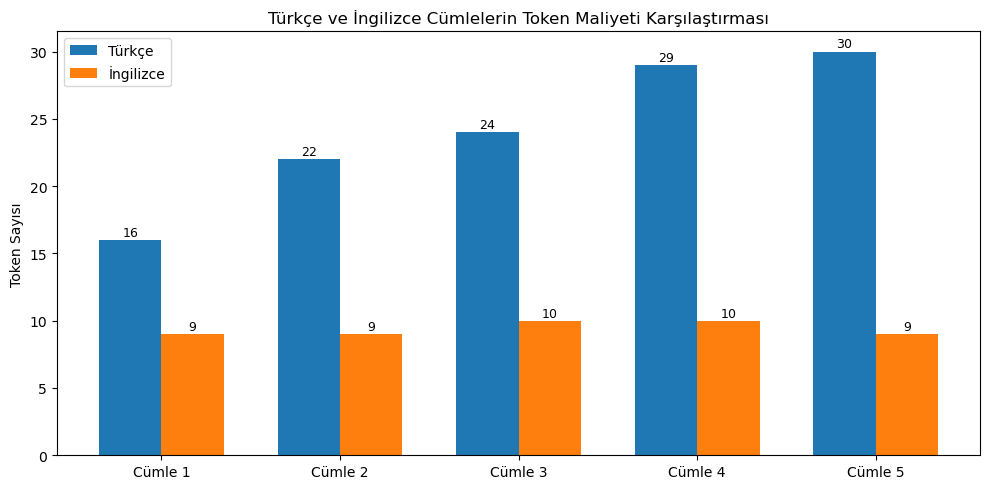


YORUM:
1) Token sayısı: Türkçe cümleler İngilizce karşılıklarından 1.8-3.3 kat (ortalama 2.57 kat) fazla token. Muhtemel neden: GPT-2'nin sözlüğü ağırlıklı İngilizce metinden çıkarıldığı için Türkçe kelimeler küçük parçalara bölünüyor (01'deki BPE deneyinin aynısı, burada daha uç).
2) Token başına kayıp: TR 5.05, EN 3.67 (1.4 kat). Ama cümle başına toplam kayıp TR 117.6, EN 30.9 (3.8 kat). Karakter başına kayıp TR 2.60, EN 0.67 (3.9 kat) ve her cümle çiftinde Türkçe 2.9-5.6 kat daha yüksek.
3) (c) Token başına kıyas neden adil değil: iki dilde bir token farklı miktarda bilgi taşıyor. Büyük olasılıkla Türkçe'de çok parçalanan kelimelerin devam parçaları kolay tahmin edildiği için token başına ortalama aşağı çekiliyor (bunu ayrıca ölçmedik) ve gerçek fark (yaklaşık 4 kat) 1.4 kat gibi küçük görünüyor. Adil kıyas için aynı içeriği taşıyan bir birim gerekir: karakter, kelime ya da cümle başına toplam kayıp.
4) Metriği değiştirmek modeli değiştirmez; karakter başına kayıp sadece ölçümü adi

In [166]:
print("\n==== Egzersiz 4: Türkçe'nin Token Maliyeti ====")

sentences_turkish = [
    "Ankara Türkiye'nin başkentidir.",
    "İstanbul, Türkiye'nin en büyük şehridir.",
    "Türkiye'nin güneyinde Akdeniz kıyıları bulunur.",
    "Türkiye, tarihi ve kültürel zenginlikleri ile ünlüdür.",
    "Türk mutfağı, dünya çapında lezzetleri ile tanınır.",
]

sentences_english = [
    "Ankara is the capital of Turkey.",
    "Istanbul is the largest city in Turkey.",
    "The southern coast of Turkey is along the Mediterranean.",
    "Turkey is famous for its historical and cultural richness.",
    "Turkish cuisine is known worldwide for its flavors.",
]

results = []

for tr_sent, en_sent in zip(sentences_turkish, sentences_english):
    # Türkçe hesaplama
    tr_ids = tok_gpt(tr_sent, return_tensors="pt").input_ids
    with torch.no_grad():
        tr_loss = gpt(input_ids=tr_ids, labels=tr_ids).loss.item()
    tr_len = tr_ids.shape[1]
    # labels=ids verildiğinde kayıp T-1 tahmin üzerinden ortalanır:
    tr_total_loss = tr_loss * (tr_len - 1)
    tr_char_count = len(tr_sent)

    # İngilizce hesaplama
    en_ids = tok_gpt(en_sent, return_tensors="pt").input_ids
    with torch.no_grad():
        en_loss = gpt(input_ids=en_ids, labels=en_ids).loss.item()
    en_len = en_ids.shape[1]
    en_total_loss = en_loss * (en_len - 1)
    en_char_count = len(en_sent)

    results.append(
        {
            "tr_sent": tr_sent,
            "en_sent": en_sent,
            "tr_tokens": tr_len,
            "en_tokens": en_len,
            "tr_loss": tr_loss,
            "en_loss": en_loss,
            "tr_total_loss": tr_total_loss,
            "en_total_loss": en_total_loss,
            "tr_loss_per_char": tr_total_loss / tr_char_count,
            "en_loss_per_char": en_total_loss / en_char_count,
        }
    )

# (a) Token Sayıları ve Oranları
print("\n--- (a) Token Sayıları ve Oranları ---")
print(
    f"{'Cümle':<8} | {'TR Token':<10} | {'EN Token':<10} | {'Oran (TR/EN)':<12}"
)
print("-" * 46)
for i, res in enumerate(results, 1):
    ratio = res["tr_tokens"] / res["en_tokens"]
    print(
        f"Cümle {i:<3} | {res['tr_tokens']:<10} | {res['en_tokens']:<10} | {ratio:.2f}x"
    )

avg_tr_tokens = np.mean([r["tr_tokens"] for r in results])
avg_en_tokens = np.mean([r["en_tokens"] for r in results])
print("-" * 46)
print(
    f"{'Ortalama':<8} | {avg_tr_tokens:<10.1f} | {avg_en_tokens:<10.1f} | {avg_tr_tokens/avg_en_tokens:.2f}x\n"
)

print("--- Cümle Başına Toplam Kayıp (Kayıp x (T-1)) ---")
for i, res in enumerate(results, 1):
    print(f"Cümle {i}:")
    print(
        f"  TR Toplam: {res['tr_total_loss']:.4f} (Ort: {res['tr_loss']:.4f}/tok, T={res['tr_tokens']})"
    )
    print(
        f"  EN Toplam: {res['en_total_loss']:.4f} (Ort: {res['en_loss']:.4f}/tok, T={res['en_tokens']})"
    )

print("\n--- (c) Karakter Başına Kayıp (toplam kayıp / cümledeki karakter sayısı) ---")
print(f"{'Cümle':<8} | {'TR kayıp/karakter':<18} | {'EN kayıp/karakter':<18} | {'Oran (TR/EN)':<12}")
print("-" * 66)
for i, res in enumerate(results, 1):
    print(f"Cümle {i:<3} | {res['tr_loss_per_char']:<18.3f} | {res['en_loss_per_char']:<18.3f} | {res['tr_loss_per_char'] / res['en_loss_per_char']:.2f}x")
print(f"\nOrtalama token başına kayıp   -> TR: {np.mean([r['tr_loss'] for r in results]):.3f} | EN: {np.mean([r['en_loss'] for r in results]):.3f}")
print(f"Ortalama karakter başına kayıp -> TR: {np.mean([r['tr_loss_per_char'] for r in results]):.3f} | EN: {np.mean([r['en_loss_per_char'] for r in results]):.3f}")
print(f"Ortalama cümle başına toplam kayıp -> TR: {np.mean([r['tr_total_loss'] for r in results]):.1f} | EN: {np.mean([r['en_total_loss'] for r in results]):.1f}")

plt.figure(figsize=(10, 5))
x = np.arange(len(results))
width = 0.35
tr_counts = [r["tr_tokens"] for r in results]
en_counts = [r["en_tokens"] for r in results]

plt.bar(x - width / 2, tr_counts, width, label="Türkçe", color="#1f77b4")
plt.bar(x + width / 2, en_counts, width, label="İngilizce", color="#ff7f0e")

for i in range(len(results)):
    plt.text(
        x[i] - width / 2,
        tr_counts[i] + 0.3,
        str(tr_counts[i]),
        ha="center",
        fontsize=9,
    )
    plt.text(
        x[i] + width / 2,
        en_counts[i] + 0.3,
        str(en_counts[i]),
        ha="center",
        fontsize=9,
    )

plt.xticks(x, [f"Cümle {i+1}" for i in range(len(results))])
plt.ylabel("Token Sayısı")
plt.title("Türkçe ve İngilizce Cümlelerin Token Maliyeti Karşılaştırması")
plt.legend()
plt.tight_layout()
plt.savefig("turkish_english_token_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

print('\nYORUM:')
print("1) Token sayısı: Türkçe cümleler İngilizce karşılıklarından 1.8-3.3 kat (ortalama 2.57 kat) fazla token. Muhtemel neden: GPT-2'nin sözlüğü ağırlıklı İngilizce metinden çıkarıldığı için Türkçe kelimeler küçük parçalara bölünüyor (01'deki BPE deneyinin aynısı, burada daha uç).")
print('2) Token başına kayıp: TR 5.05, EN 3.67 (1.4 kat). Ama cümle başına toplam kayıp TR 117.6, EN 30.9 (3.8 kat). Karakter başına kayıp TR 2.60, EN 0.67 (3.9 kat) ve her cümle çiftinde Türkçe 2.9-5.6 kat daha yüksek.')
print("3) (c) Token başına kıyas neden adil değil: iki dilde bir token farklı miktarda bilgi taşıyor. Büyük olasılıkla Türkçe'de çok parçalanan kelimelerin devam parçaları kolay tahmin edildiği için token başına ortalama aşağı çekiliyor (bunu ayrıca ölçmedik) ve gerçek fark (yaklaşık 4 kat) 1.4 kat gibi küçük görünüyor. Adil kıyas için aynı içeriği taşıyan bir birim gerekir: karakter, kelime ya da cümle başına toplam kayıp.")
print("4) Metriği değiştirmek modeli değiştirmez; karakter başına kayıp sadece ölçümü adil yapar. Modeli ya da tokenizer'ı Türkçe'ye uyarlamak ayrı bir iş (01'deki gibi Türkçe korpusta BPE).")
print("5) Sınırlama: bu deneyle iki etkiyi ayıramıyoruz: (i) Türkçe'nin çok parçalanması, (ii) GPT-2'nin Türkçe'yi az bilmesi. Ayrıca sadece 5 cümle çifti var.")
print("6) (d) Tez bağlantısı: Türkçe metin ~2.5 kat token demek. 1024 token'lık pencere Türkçe'de ~2.5 kat daha az metin alır. RAG'de (#15) chunk boyutu ve prompt'a kaç chunk sığacağı, token başına ücretli API'lerde maliyet bundan etkilenir. #22 (hafif Transformer + Türkçe) ve #12 (Türkçe benchmark) için tokenizer/model seçimi ilk kararlardan biri.")

### Egzersiz 5 — Kafa avı: kim neye bakıyor?

GPT-2'nin 12 blok × 12 kafa = 144 kafası var. `gpt(ids, output_attentions=True).attentions` her blok için `(1, 12, T, T)` şeklinde ağırlık döndürüyor.

(a) En az 3 cümle üzerinde her kafa için **"bir önceki token'a ortalama dikkat"** ( `w[i, i-1]` ortalaması, `i >= 1`) hesapla ve `12 × 12` bir ısı haritası çiz (satır = blok, sütun = kafa).

(b) Aynısını **"ilk token'a ortalama dikkat"** için yap (`w[i, 0]`, `i >= 1`). Hangi bloklarda yüksek?

(c) "Önceki token" haritasındaki en yüksek kafayı bul ve o kafanın ağırlıklarını `plot_attn` ile çiz. Mantıklı bir görev mi yapıyor?

(d) 05'te ya da 04'te gördüğün hangi fikirle bağlantılı: kafalar özelleşiyor mu? Kısaca yaz.

==== Egzersiz 5: Kafa avı ====


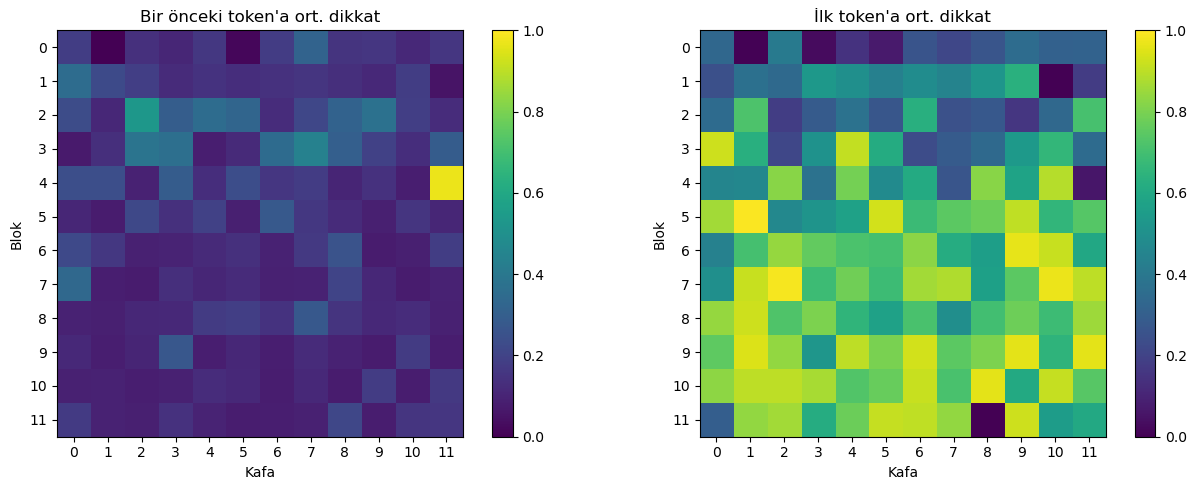

İlk token'a dikkat, blok ortalaması: [0.23 0.39 0.38 0.52 0.55 0.74 0.72 0.79 0.73 0.82 0.82 0.68]
En 'önceki token' kafası: blok 4, kafa 11  (ort. dikkat = 0.971)


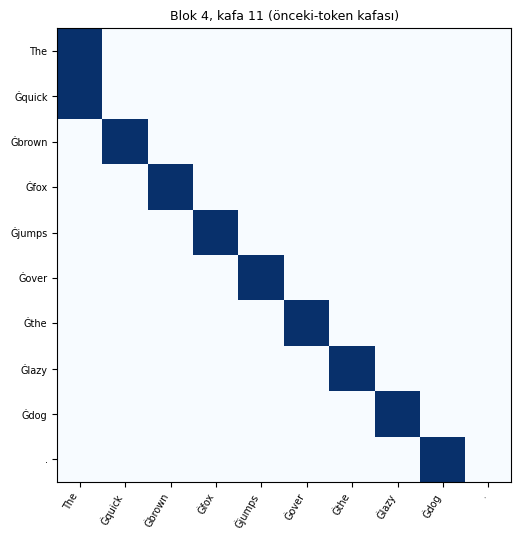

Önceki-token dikkati > 0.5 olan kafa sayısı: 2 / 144
İlk-token dikkati    > 0.5 olan kafa sayısı: 97 / 144

YORUM (E5):
(a) Sadece 2/144 kafa ağırlığının yarısından fazlasını bir önceki token'a veriyor; en belirgini blok 4 / kafa 11 (ort. 0.97, neredeyse hep bir soldaki token'a bakıyor). Yani "önceki token" kafası nadir ama çok net bir uzman.
(b) İlk token'a dikkat bloklarla artıyor: blok 0'da ~0.23, blok 5-10'da ~0.7-0.8 (blok 11'de 0.68'e iniyor). 144 kafanın 97'si dikkatinin yarısından fazlasını ilk token'a veriyor. İlk token bir bilgi kaynağı değil, "boşta kalan dikkatin park yeri" (attention sink); Bölüm 6'daki devasa ilk-token vektörüyle uyumlu. Tez #10 (uzun bağlam) burada.
(c) Blok 4 / kafa 11'in haritası köşegenin hemen altında tek çizgi: her token bir soldakine bakıyor. Mantıklı bir iş: "bir önceki kelime ne?" bilgisini sonraki bloklara taşıyor (bigram benzeri bilgi).
(d) Bağlantı 04: kafalar farklı iş bölüşüyor (bir kısmı önceki token, bir kısmı ilk token/sink, gerisi daha d

In [193]:
print("==== Egzersiz 5: Kafa avı ====")
sents_ex5 = [
    "The quick brown fox jumps over the lazy dog.",
    "In a galaxy far, far away, an epic battle unfolds between the forces of good and evil.",
    "The art of programming is a blend of logic, creativity, and problem-solving skills.",
]

onceki = np.zeros((12, 12))   # satır = blok, sütun = kafa
ilk    = np.zeros((12, 12))
for s in sents_ex5:
    ids_e5 = tok_gpt(s, return_tensors="pt").input_ids
    T = ids_e5.shape[1]
    att = gpt(ids_e5, output_attentions=True).attentions       # 12 x (1, 12, T, T)
    for b in range(12):
        w = att[b][0]                                           # (12 kafa, T, T)
        # (a) w[i, i-1]: köşegenin bir altı; i>=1 için ortalama
        onceki[b] += torch.diagonal(w, offset=-1, dim1=-2, dim2=-1).mean(-1).numpy() / len(sents_ex5)
        # (b) w[i, 0]: ilk sütun; i>=1 için ortalama (i=0 satırı ilk token'ın kendine bakışı, dışarıda)
        ilk[b]    += w[:, 1:, 0].mean(-1).numpy() / len(sents_ex5)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, M, ad in [(axes[0], onceki, "Bir önceki token'a ort. dikkat"), (axes[1], ilk, "İlk token'a ort. dikkat")]:
    im = ax.imshow(M, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(ad); ax.set_xlabel("Kafa"); ax.set_ylabel("Blok")
    ax.set_xticks(range(12)); ax.set_yticks(range(12))
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

# (b) blok bazında: ilk token'a dikkat (12 kafa ortalaması)
print("İlk token'a dikkat, blok ortalaması:", ilk.mean(1).round(2))

# (c) "önceki token" haritasının en yüksek kafası
b_max, h_max = np.unravel_index(onceki.argmax(), onceki.shape)
print(f"En 'önceki token' kafası: blok {b_max}, kafa {h_max}  (ort. dikkat = {onceki[b_max, h_max]:.3f})")
ids_e5 = tok_gpt(sents_ex5[0], return_tensors="pt").input_ids
w_top = gpt(ids_e5, output_attentions=True).attentions[b_max][0, h_max].numpy()
fig, ax = plt.subplots(figsize=(6, 5.5))
plot_attn(ax, w_top, tok_gpt.convert_ids_to_tokens(ids_e5[0]), f"Blok {b_max}, kafa {h_max} (önceki-token kafası)")
plt.tight_layout(); plt.show()

# (d) bu 144 kafanın kaçı "önceki token" veya "ilk token" uzmanı?
print("Önceki-token dikkati > 0.5 olan kafa sayısı:", int((onceki > 0.5).sum()), "/ 144")
print("İlk-token dikkati    > 0.5 olan kafa sayısı:", int((ilk > 0.5).sum()), "/ 144")

print("""
YORUM (E5):
(a) Sadece 2/144 kafa ağırlığının yarısından fazlasını bir önceki token'a veriyor; en belirgini blok 4 / kafa 11 (ort. 0.97, neredeyse hep bir soldaki token'a bakıyor). Yani "önceki token" kafası nadir ama çok net bir uzman.
(b) İlk token'a dikkat bloklarla artıyor: blok 0'da ~0.23, blok 5-10'da ~0.7-0.8 (blok 11'de 0.68'e iniyor). 144 kafanın 97'si dikkatinin yarısından fazlasını ilk token'a veriyor. İlk token bir bilgi kaynağı değil, "boşta kalan dikkatin park yeri" (attention sink); Bölüm 6'daki devasa ilk-token vektörüyle uyumlu. Tez #10 (uzun bağlam) burada.
(c) Blok 4 / kafa 11'in haritası köşegenin hemen altında tek çizgi: her token bir soldakine bakıyor. Mantıklı bir iş: "bir önceki kelime ne?" bilgisini sonraki bloklara taşıyor (bigram benzeri bilgi).
(d) Bağlantı 04: kafalar farklı iş bölüşüyor (bir kısmı önceki token, bir kısmı ilk token/sink, gerisi daha dağınık). 04'te 5 kafanın farklı davrandığını görmüştük; burada aynısı 144 kafada ve gerçek modelde.
""")


### Egzersiz 6 — Sağ bağlam kimin işine yarıyor?

(a) Cümlenin **sadece sağ tarafı** farklı olan iki çift kur (örnek: `"i went to the [MASK] to buy medicine."` ve `"i went to the [MASK] to borrow books."`). `bert_bosluk` ile boşluk tahminlerini karşılaştır.

(b) Aynı iki cümle için `gpt_devam("i went to the")` ne veriyor? Neden sağ bağlamdan hiç etkilenemiyor?

(c) GPT-2'nin sağ bağlamdan yararlanmasının bir yolu var mı? (İpucu: boşluğu sona alacak şekilde cümleyi yeniden yaz, örn. `"To buy medicine, I went to the"`. Bu, modele hangi bilgiyi veriyor?)

(d) Bu durum neden bugünkü sohbet modellerinin (GPT tarzı) prompt yazma biçimini etkiliyor? Bir cümle yaz.

In [194]:
print("==== Egzersiz 6: Sağ bağlam kimin işine yarıyor? ====")
# (a) Sadece sağ taraf farklı olan çift
cift = ["i went to the [MASK] to buy medicine.", "i went to the [MASK] to borrow books."]
for c in cift:
    print("BERT:", c, "->", bert_bosluk(c))

# (b) GPT-2 için ikisi de aynı prefix: "i went to the"
print("GPT-2:", "i went to the", "->", gpt_devam("i went to the"))

# (c) Boşluğu sona alıp sağ bağlamı sola taşıyalım
for c in ["To buy medicine, I went to the", "To borrow books, I went to the"]:
    print("GPT-2:", c, "->", gpt_devam(c))

# Senin cümlelerin: BERT (sağ bağlamlı) vs GPT-2 (aynı bilgi solda)
print()
for sag, sol in [("I went to the [MASK] to buy some groceries.", "To buy some groceries, I went to the"),
                 ("I went to the [MASK] to watch a movie.", "To watch a movie, I went to the"),
                 ("I went to the [MASK] to get a haircut.", "To get a haircut, I went to the")]:
    print("BERT :", sag, "->", bert_bosluk(sag))
    print("GPT-2:", sol, "->", gpt_devam(sol))

print("""
YORUM (E6):
(a) BERT, sağ tarafı görüyor: "medicine" ile 'store/pharmacy', "borrow books" ile 'library/bookstore' çıktı; iki cümlenin sol tarafı aynı ama tahminler değişti. (BERT her zaman doğru değil: "watch a movie" için 'bathroom', "haircut" için 'bathroom' birinci çıktı.)
(b) GPT-2 iki cümle için de aynı prefix'i ("i went to the") görüyor ve çıktısı birebir aynı: hospital, doctor, bathroom... Causal mask yüzünden bir konum sağdaki token'ı hiç göremez; sağ taraf ne olursa olsun tahmin değişemez.
(c) Bilgiyi sola taşıyınca GPT-2 kurtuldu: "To buy medicine, I went to the" -> pharmacy; "To borrow books..." -> library; "To watch a movie..." -> theater; "To get a haircut..." -> salon. Model, amacı "okumuş" oluyor ve boşluğu buna göre dolduruyor. Bu örneklerde GPT-2 BERT'ten iyi çıktı, ama bu genel bir üstünlük değil; sadece bilgi soldaydı.
(d) GPT tarzı sohbet modelleri sağı göremediği için önemli bilgiyi (görev, bağlam, kısıt) cevap/soru kısmından ÖNCE yazmak gerekir; prompt yazma bu yüzden "önce bağlam, sonra soru" düzeninde.
""")


==== Egzersiz 6: Sağ bağlam kimin işine yarıyor? ====
BERT: i went to the [MASK] to buy medicine. -> ['store', 'pharmacy', 'market', 'shop', 'hospital']
BERT: i went to the [MASK] to borrow books. -> ['library', 'bookstore', 'store', 'bathroom', 'office']
GPT-2: i went to the -> [' hospital', ' doctor', ' bathroom', ' police', ' gym']
GPT-2: To buy medicine, I went to the -> [' pharmacy', ' doctor', ' hospital', ' local', ' clinic']
GPT-2: To borrow books, I went to the -> [' library', ' bookstore', ' local', ' book', ' University']

BERT : I went to the [MASK] to buy some groceries. -> ['store', 'supermarket', 'market', 'mall', 'grocery']
GPT-2: To buy some groceries, I went to the -> [' grocery', ' store', ' local', ' supermarket', ' nearest']
BERT : I went to the [MASK] to watch a movie. -> ['bathroom', 'theater', 'cinema', 'couch', 'library']
GPT-2: To watch a movie, I went to the -> [' theater', ' cinema', ' movie', ' movies', ' library']
BERT : I went to the [MASK] to get a hairc

### Egzersiz 7 (İsteğe bağlı) — Cross-attention'a bak

Bölüm 7'deki `t5` ve `tok_t5` ile `"translate English to German: The house is wonderful."` cümlesini çevirirken decoder'ın kaynak cümleye nereye baktığını çiz.

(a) `t5(input_ids=girdi_ex, decoder_input_ids=cikti_ex, output_attentions=True)` ile `cross_attentions` al (`girdi_ex`: kaynak token'lar, `cikti_ex`: `t5.generate` çıktısı; `generate` çıktısı `decoder_start_token_id` ile başlıyor).

(b) Son decoder bloğunun kafalarını ortalayıp `(üretilen token) × (kaynak token)` ısı haritası çiz. Çeviri sözcüklerinin kaynak kelimelerle hizalandığını görebiliyor musun?

(c) Bu haritanın şekli Bölüm 7'deki cross-attention tablosuyla (dikdörtgen) aynı mı?


==== Egzersiz 7: Cross Attention'a BAK ====


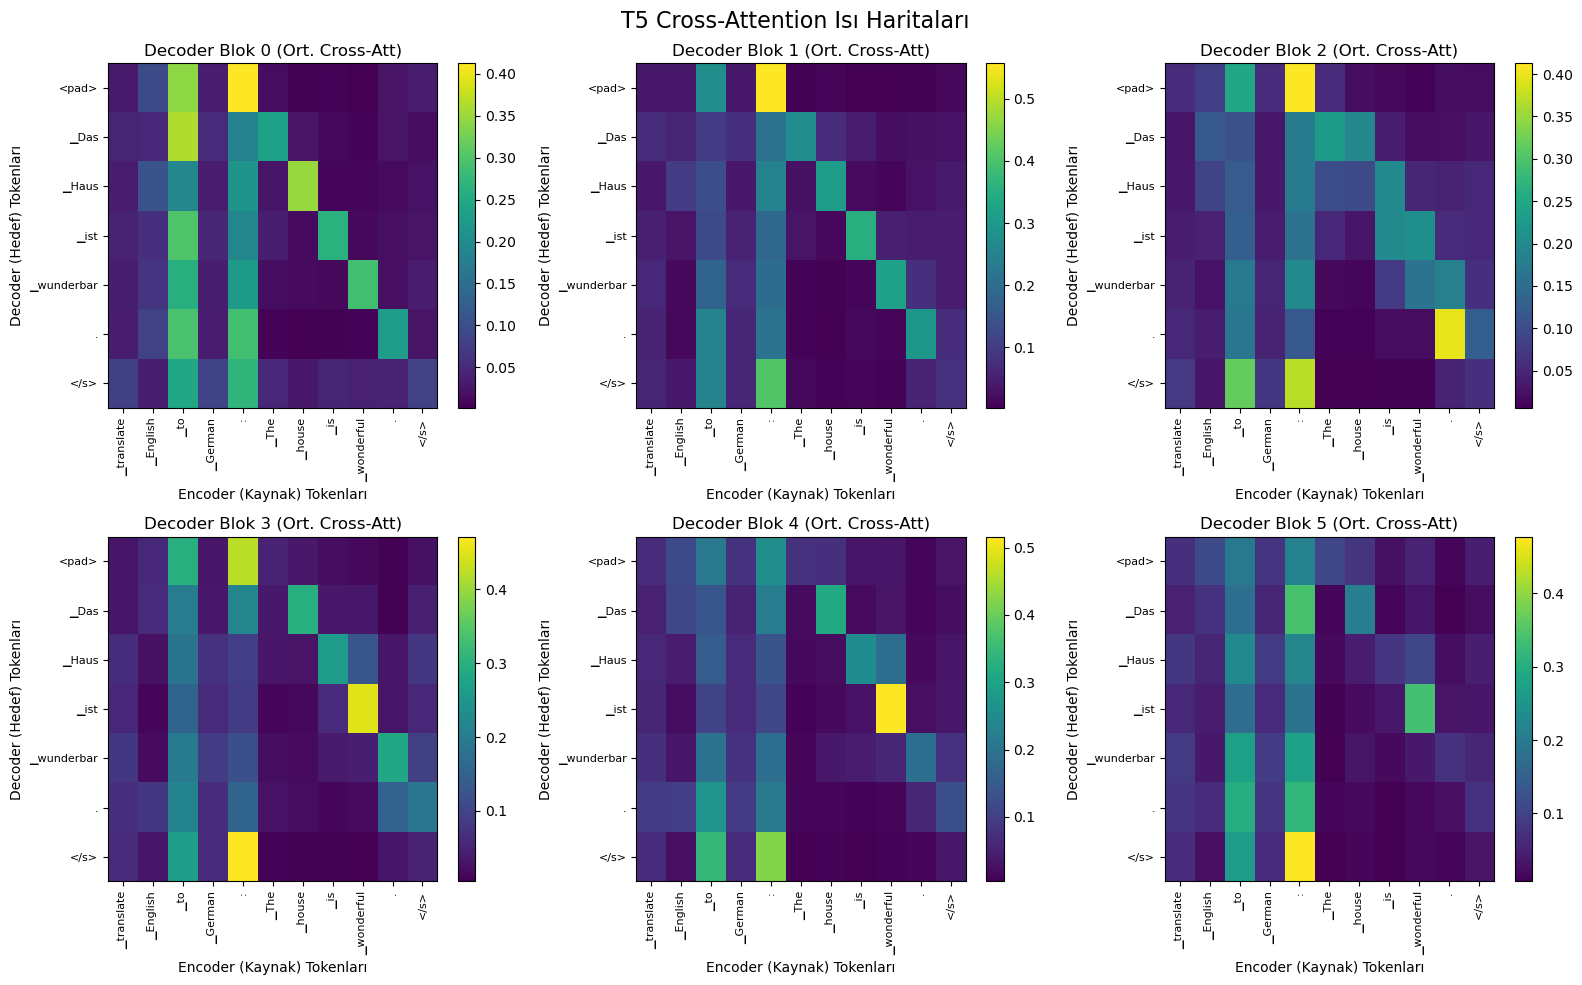

Kaynak: ['▁translate', '▁English', '▁to', '▁German', ':', '▁The', '▁house', '▁is', '▁wonderful', '.', '</s>']
Hedef : ['<pad>', '▁Das', '▁Haus', '▁ist', '▁wunderbar', '.', '</s>']
Isı haritası şekli (hedef x kaynak): (7, 11)
▁Haus       en çok baktığı kaynak token, blok 0..5: ['▁house', '▁house', '▁is', '▁is', '▁is', '▁to']
▁wunderbar  en çok baktığı kaynak token, blok 0..5: ['▁wonderful', '▁wonderful', ':', '.', '▁to', ':']
▁ist        en çok baktığı kaynak token, blok 0..5: ['▁to', '▁is', '▁wonderful', '▁wonderful', '▁wonderful', '▁wonderful']

YORUM (E7):
(b) Hizalama var ama zayıf ve her blokta yok. Blok 0-1'de 'Haus' -> 'house' ve 'wunderbar' -> 'wonderful' en yüksek dikkati alıyor (0.3 civarı); son bloklarda 'ist' -> 'wonderful' gibi başka kaymalar var, bazı token'lar ('Das', '.', '</s>') ':' gibi anlamsız kaynak token'larına yığılıyor (yine bir tür sink). Yani "her blokta house-Haus" doğru değil; ortalamayı alınca dikkat da dağınık (0.3-0.5 seviyesinde).
(c) Şekil dikdörtgen: 7 

In [195]:
print("\n==== Egzersiz 7: Cross Attention'a BAK ====")
from transformers import T5ForConditionalGeneration, T5Tokenizer
tok_t5 = T5Tokenizer.from_pretrained("t5-small")
t5 = T5ForConditionalGeneration.from_pretrained("t5-small", attn_implementation="eager").eval()

girdi_ex7 = tok_t5("translate English to German: The house is wonderful.", return_tensors="pt").input_ids
cikti_ex7 = t5.generate(girdi_ex7, max_new_tokens=30, num_beams=1, do_sample=False)
with torch.no_grad():
    cross_attention_inputs = t5(input_ids=girdi_ex7, decoder_input_ids=cikti_ex7, output_attentions=True)

# cross_attentions: Her katman için (batch_size, num_heads, seq_len_dec, seq_len_enc) boyutunda 6 elemanlı tuple
cross_attentions = cross_attention_inputs.cross_attentions 
cross_attentions = torch.stack(cross_attentions)  # [katman_sayisi, num_heads, seq_len_dec, seq_len_enc]

# Tüm kafaların (heads) ortalamasını alalım
avg_cross_attentions = cross_attentions.mean(dim=1).mean(dim=1).detach().cpu().numpy()
# Token etiketlerini grafik eksenlerine yazmak için alalım
encoder_labels = tok_t5.convert_ids_to_tokens(girdi_ex7[0])
decoder_labels = tok_t5.convert_ids_to_tokens(cikti_ex7[0])
plt.figure(figsize=(16, 10))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(avg_cross_attentions[i], cmap="viridis", aspect="auto")
    plt.colorbar()
    
    # Eksen etiketlerini token isimleriyle değiştirme
    plt.xticks(range(len(encoder_labels)), encoder_labels, rotation=90, fontsize=8)
    plt.yticks(range(len(decoder_labels)), decoder_labels, fontsize=8)
    
    plt.title(f"Decoder Blok {i} (Ort. Cross-Att)")
    plt.xlabel("Encoder (Kaynak) Tokenları")
    plt.ylabel("Decoder (Hedef) Tokenları")

plt.suptitle("T5 Cross-Attention Isı Haritaları", fontsize=16)
plt.tight_layout()
plt.show()

print("Kaynak:", encoder_labels)
print("Hedef :", decoder_labels)
print("Isı haritası şekli (hedef x kaynak):", avg_cross_attentions[-1].shape)
for kelime in ["▁Haus", "▁wunderbar", "▁ist"]:
    j = decoder_labels.index(kelime)
    print(f"{kelime:11s} en çok baktığı kaynak token, blok 0..5:", [encoder_labels[avg_cross_attentions[b][j].argmax()] for b in range(6)])

print("""
YORUM (E7):
(b) Hizalama var ama zayıf ve her blokta yok. Blok 0-1'de 'Haus' -> 'house' ve 'wunderbar' -> 'wonderful' en yüksek dikkati alıyor (0.3 civarı); son bloklarda 'ist' -> 'wonderful' gibi başka kaymalar var, bazı token'lar ('Das', '.', '</s>') ':' gibi anlamsız kaynak token'larına yığılıyor (yine bir tür sink). Yani "her blokta house-Haus" doğru değil; ortalamayı alınca dikkat da dağınık (0.3-0.5 seviyesinde).
(c) Şekil dikdörtgen: 7 (üretilen: <pad> başlangıç dahil) x 11 (kaynak), çünkü satır sayısı hedef, sütun sayısı kaynak uzunluğu; self-attention'daki gibi kare değil ve causal mask yok (decoder kaynağın tamamına bakabiliyor).
""")


## Kaynaklar

- Vaswani, A., Shazeer, N., Parmar, N., et al. (2017). *Attention Is All You Need.* [arXiv:1706.03762](https://arxiv.org/abs/1706.03762) — orijinal encoder-decoder Transformer (Bölüm 3: mimari, 3.3: position-wise FFN).
- Radford, A., Wu, J., Child, R., Luan, D., Amodei, D., Sutskever, I. (2019). *Language Models are Unsupervised Multitask Learners.* [OpenAI (pdf)](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf) — GPT-2. LayerNorm'un her alt parçanın girişine taşınması (pre-LN) ve model boyutları burada.
- Devlin, J., Chang, M.-W., Lee, K., Toutanova, K. (2018). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.* [arXiv:1810.04805](https://arxiv.org/abs/1810.04805) — encoder-only aile.
- Raffel, C., Shazeer, N., Roberts, A., et al. (2019). *Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer.* [arXiv:1910.10683](https://arxiv.org/abs/1910.10683) — T5 (encoder-decoder).
- Alammar, J. *The Illustrated GPT-2 (Visualizing Transformer Language Models).* [jalammar.github.io/illustrated-gpt2](https://jalammar.github.io/illustrated-gpt2/) — **bu notebook'la birlikte okumak için en uygun kaynak.** Masked self-attention ve decoder bloğu adım adım çizimlerle.
- Ba, J. L., Kiros, J. R., Hinton, G. E. (2016). *Layer Normalization.* [arXiv:1607.06450](https://arxiv.org/abs/1607.06450).
- He, K., Zhang, X., Ren, S., Sun, J. (2015). *Deep Residual Learning for Image Recognition.* [arXiv:1512.03385](https://arxiv.org/abs/1512.03385) — residual bağlantılar (Transformer'a görüntü tanımadan geldi).
- Xiong, R., Yang, Y., He, D., et al. (2020). *On Layer Normalization in the Transformer Architecture.* ICML 2020. [arXiv:2002.04745](https://arxiv.org/abs/2002.04745) — pre-LN ile post-LN farkı ve neden pre-LN'in eğitimi kolaylaştırdığı.
- Hendrycks, D., Gimpel, K. (2016). *Gaussian Error Linear Units (GELUs).* [arXiv:1606.08415](https://arxiv.org/abs/1606.08415).
- Elhage, N., Nanda, N., Olsson, C., et al. (2021). *A Mathematical Framework for Transformer Circuits.* [transformer-circuits.pub/2021/framework](https://transformer-circuits.pub/2021/framework/index.html) — "residual stream" bakış açısı (Bölüm 6). İleri okuma, matematik ağır.
- Geva, M., Schuster, R., Berant, J., Levy, O. (2021). *Transformer Feed-Forward Layers Are Key-Value Memories.* EMNLP 2021. [arXiv:2012.14913](https://arxiv.org/abs/2012.14913) — FFN'in modelin bilgi depolayan kısmı olduğuna dair (Bölüm 2).
- Xiao, G., Tian, Y., Chen, B., Han, S., Lewis, M. (2023). *Efficient Streaming Language Models with Attention Sinks.* ICLR 2024. [arXiv:2309.17453](https://arxiv.org/abs/2309.17453) — ilk token'a biriken dikkat ("attention sink") ve uzun bağlam (tez konusu #10 için ileri okuma).
- Sun, M., Chen, X., Kolter, J. Z., Liu, Z. (2024). *Massive Activations in Large Language Models.* COLM 2024. [arXiv:2402.17762](https://arxiv.org/abs/2402.17762) — Bölüm 6'da gördüğümüz devasa ilk-token vektörleri.
- Model ağırlıkları: Hugging Face `gpt2`, `bert-base-uncased`, `t5-small`. [huggingface.co/openai-community/gpt2](https://huggingface.co/openai-community/gpt2)